

AIM :   The goal is to classify countries into different pollution severity categories (Low, Medium, High) based on pollution levels, energy consumption, and other environmental factors.

Step 1 - Data Import and Preprocessing


In [37]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv('Global_Pollution_Analysis.csv')

In [39]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [40]:
df.shape

(200, 13)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

NO - NULL 

In [42]:
(df == "").sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df_new = df.copy()

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_new[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']] = scaler.fit_transform(df_new[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']])

     

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_new['Country'] = le.fit_transform(df['Country'])
df_new['Year'] = le.fit_transform(df['Year'])
     

In [47]:
df_new.tail()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
195,92,4,-0.968336,-0.765207,-0.862482,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,13,2,-0.878956,0.124351,-0.316683,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,88,11,-0.461800,0.671106,-0.996342,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,170,2,0.845568,-0.030300,0.643326,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01
199,41,10,-0.674489,0.913617,0.336204,36182.44,172.24,5.55,45.96,45405.35,11.72,166.62,30304.59


In [48]:
df.sort_values(by='Year')['Year']

14     2000
10     2000
25     2000
39     2000
42     2000
       ... 
62     2019
169    2019
132    2019
131    2019
157    2019
Name: Year, Length: 200, dtype: int64

So data is from year 2000 to 2019 

Step 2 - Exploratory Data Analysis (EDA)


In [49]:
df_new.describe()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,88.575000,9.335000,7.549517e-17,-3.552714e-16,2.486900e-16,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,49.924107,5.765325,1.002509e+00,1.002509e+00,1.002509e+00,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,0.000000,0.000000,-1.947928e+00,-1.768540e+00,-1.650240e+00,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,45.750000,4.000000,-6.823730e-01,-8.536990e-01,-8.989775e-01,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,90.500000,10.000000,4.122312e-02,-5.821733e-02,5.332837e-02,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,131.000000,14.000000,8.489305e-01,8.935479e-01,8.265007e-01,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,174.000000,19.000000,1.753566e+00,1.775151e+00,1.837213e+00,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [50]:
# df.describe().corr()

In [51]:
correlation = df_new.corr(numeric_only=True)["Energy_Recovered (in GWh)"]
correlation

Country                                  -0.044316
Year                                      0.088332
Air_Pollution_Index                       0.002997
Water_Pollution_Index                    -0.041828
Soil_Pollution_Index                      0.064076
Industrial_Waste (in tons)               -0.161309
Energy_Recovered (in GWh)                 1.000000
CO2_Emissions (in MT)                     0.024758
Renewable_Energy (%)                      0.043533
Plastic_Waste_Produced (in tons)         -0.072946
Energy_Consumption_Per_Capita (in MWh)   -0.030284
Population (in millions)                 -0.075100
GDP_Per_Capita (in USD)                   0.004535
Name: Energy_Recovered (in GWh), dtype: float64

<Axes: >

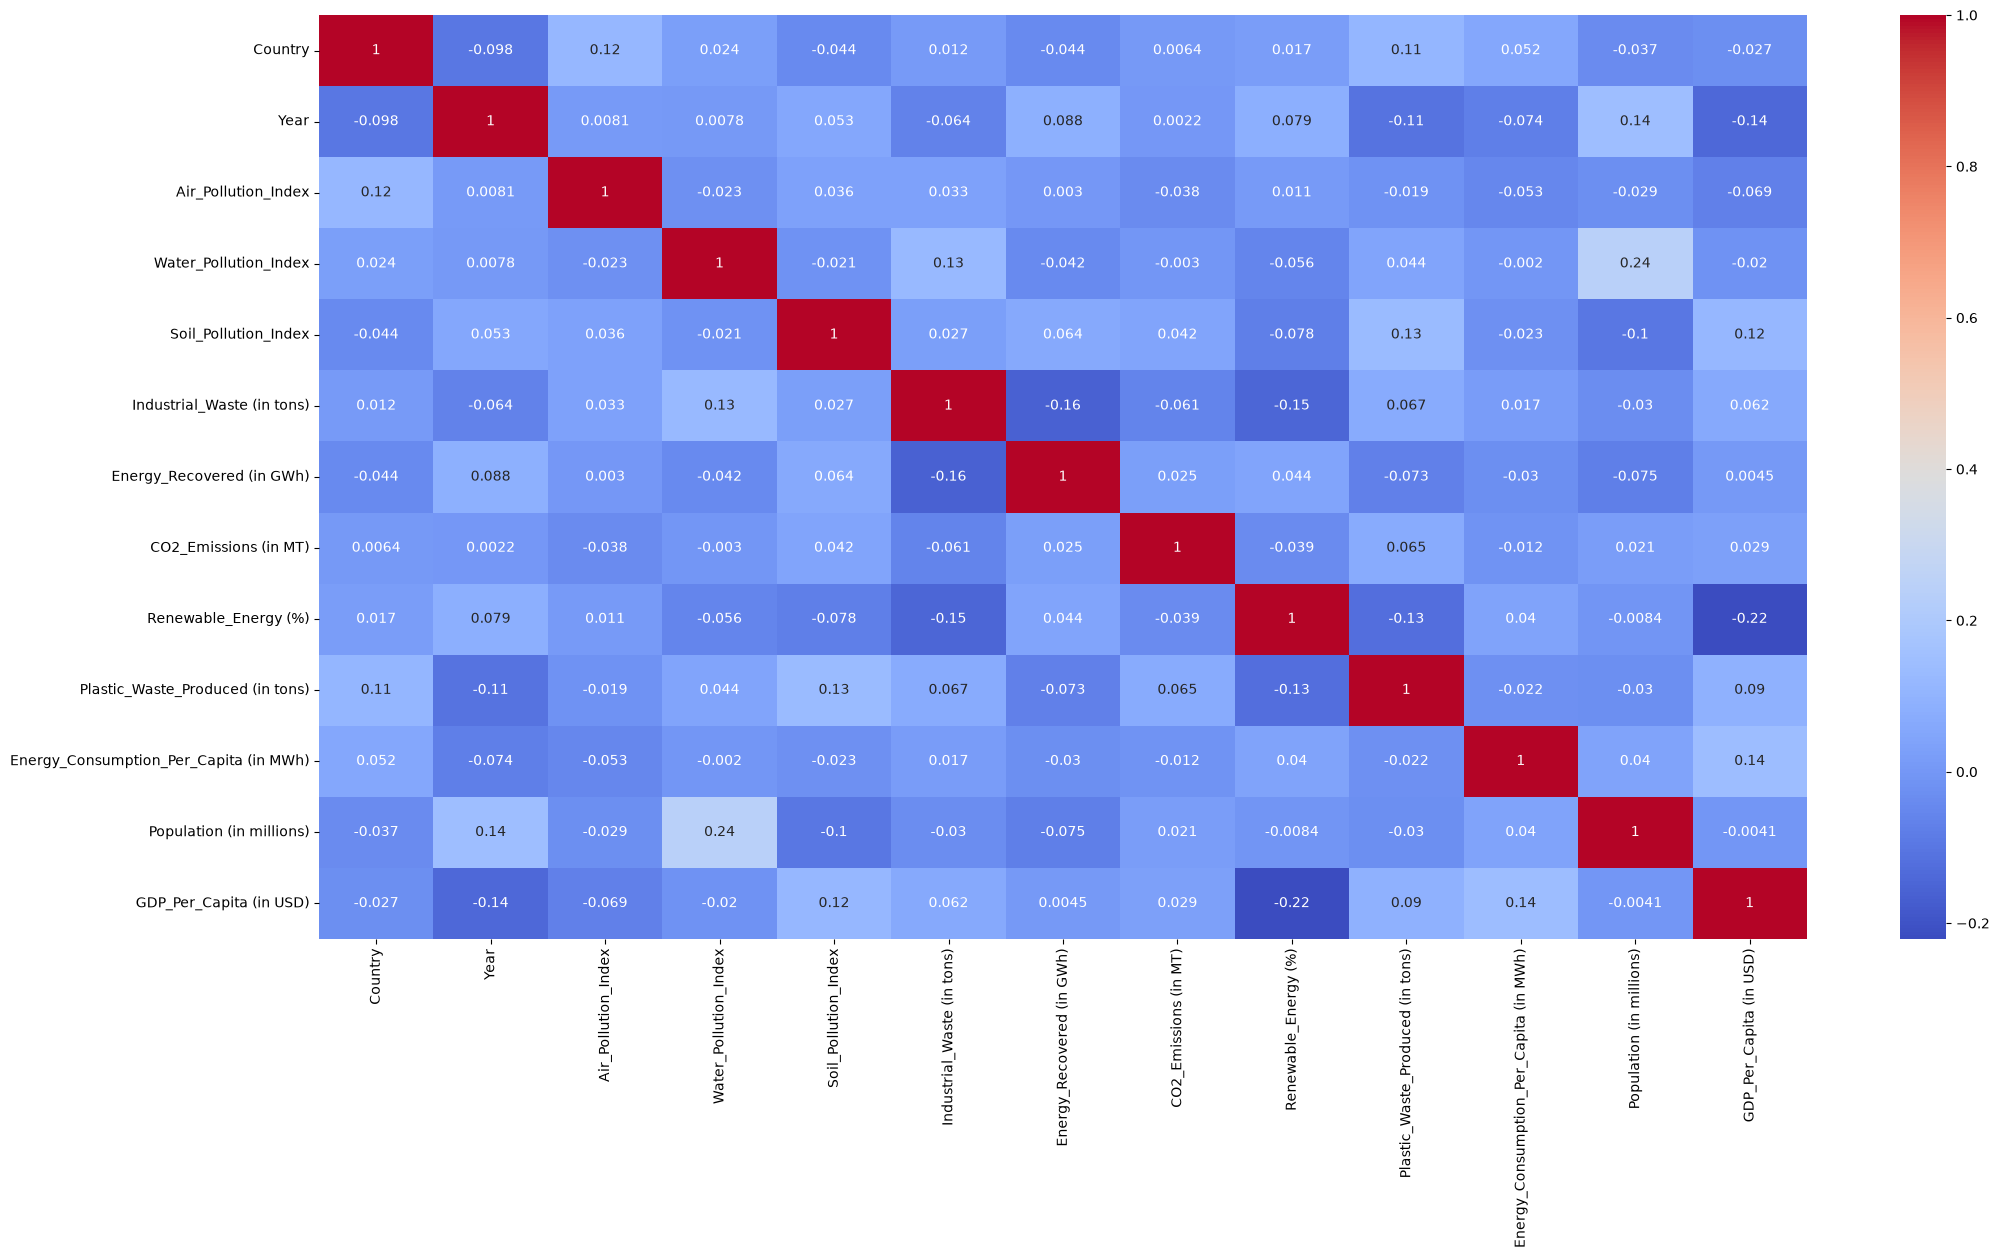

In [52]:
plt.figure(figsize=(24,12))
sns.heatmap(df_new.corr(numeric_only=True), annot=True ,cmap = "coolwarm")

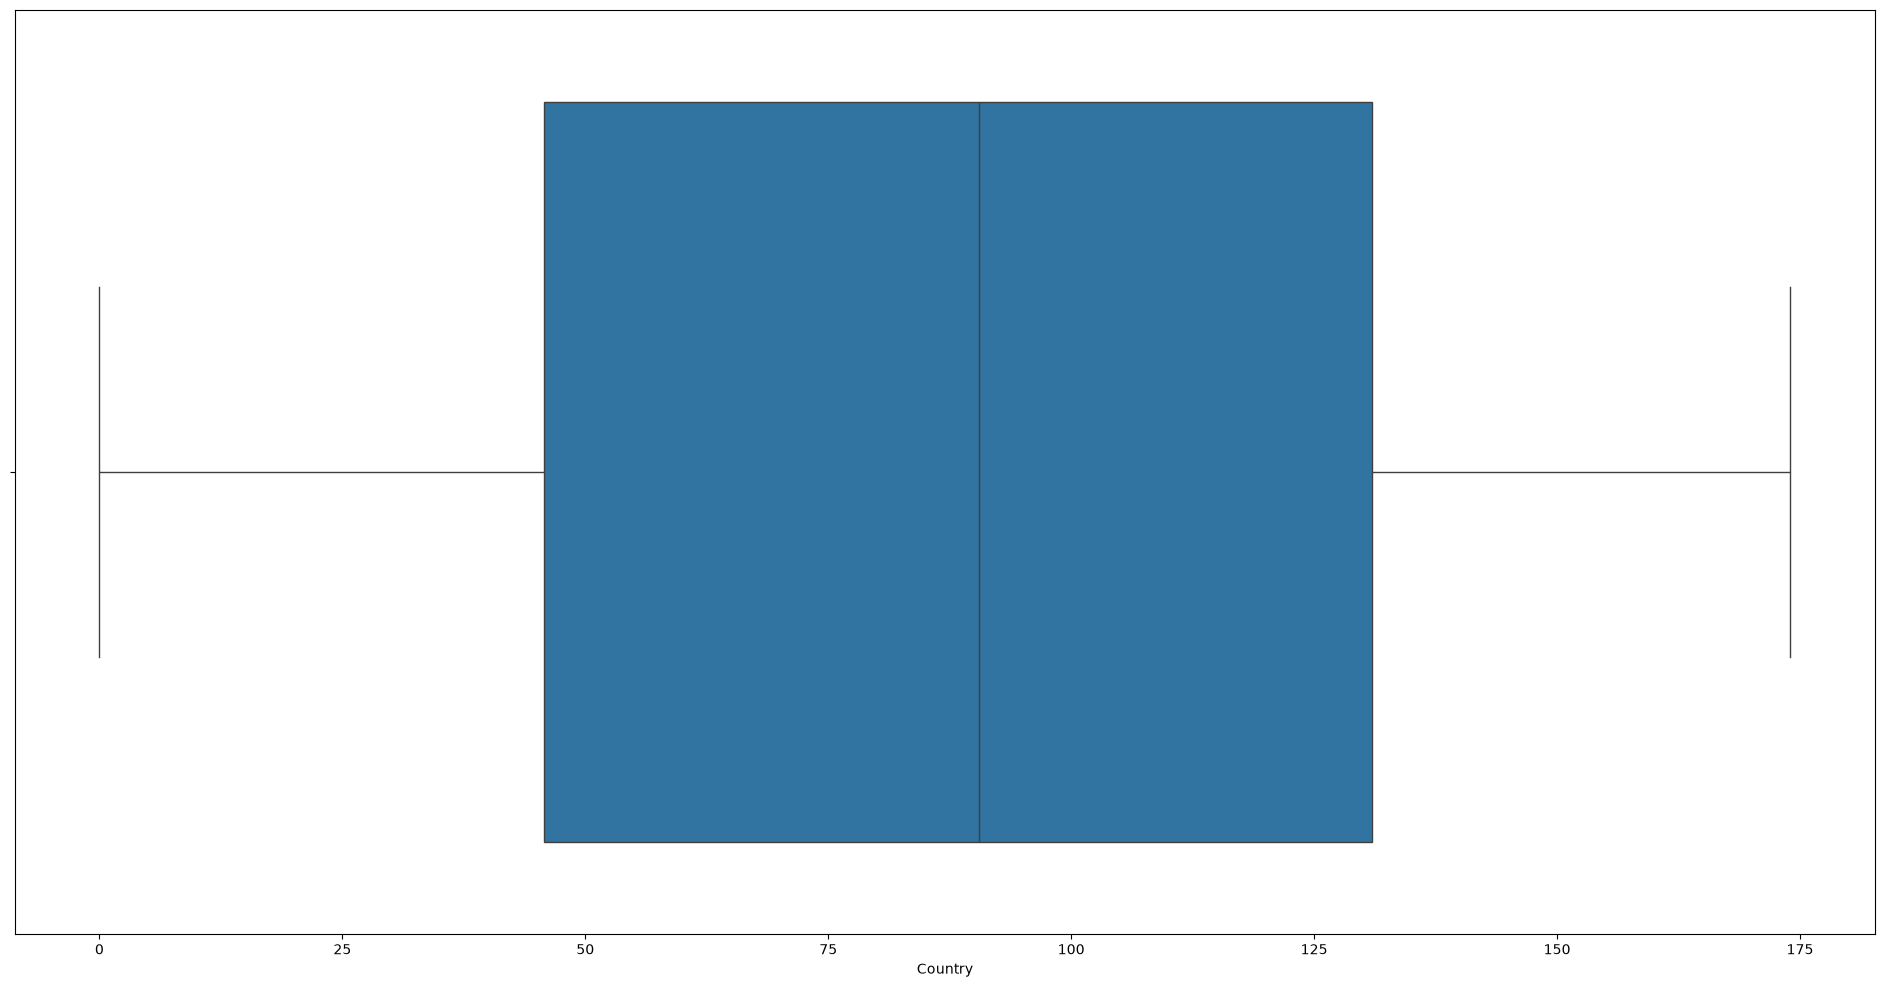

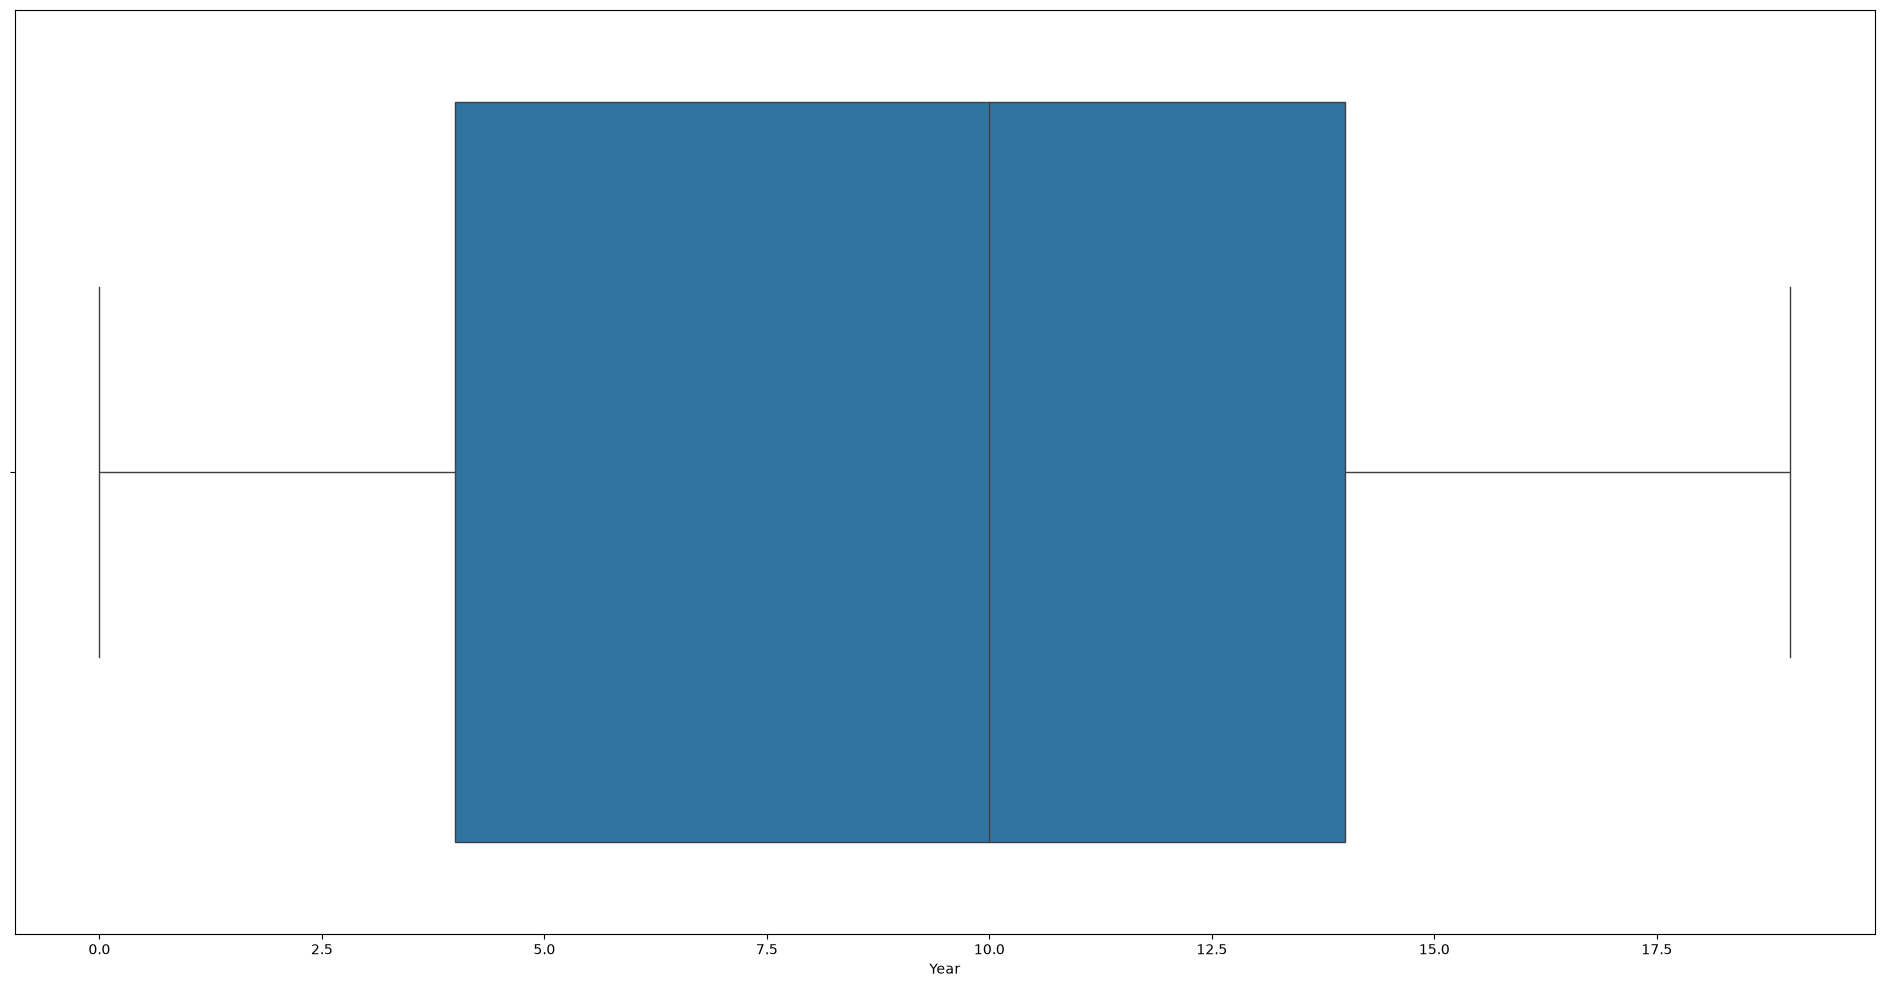

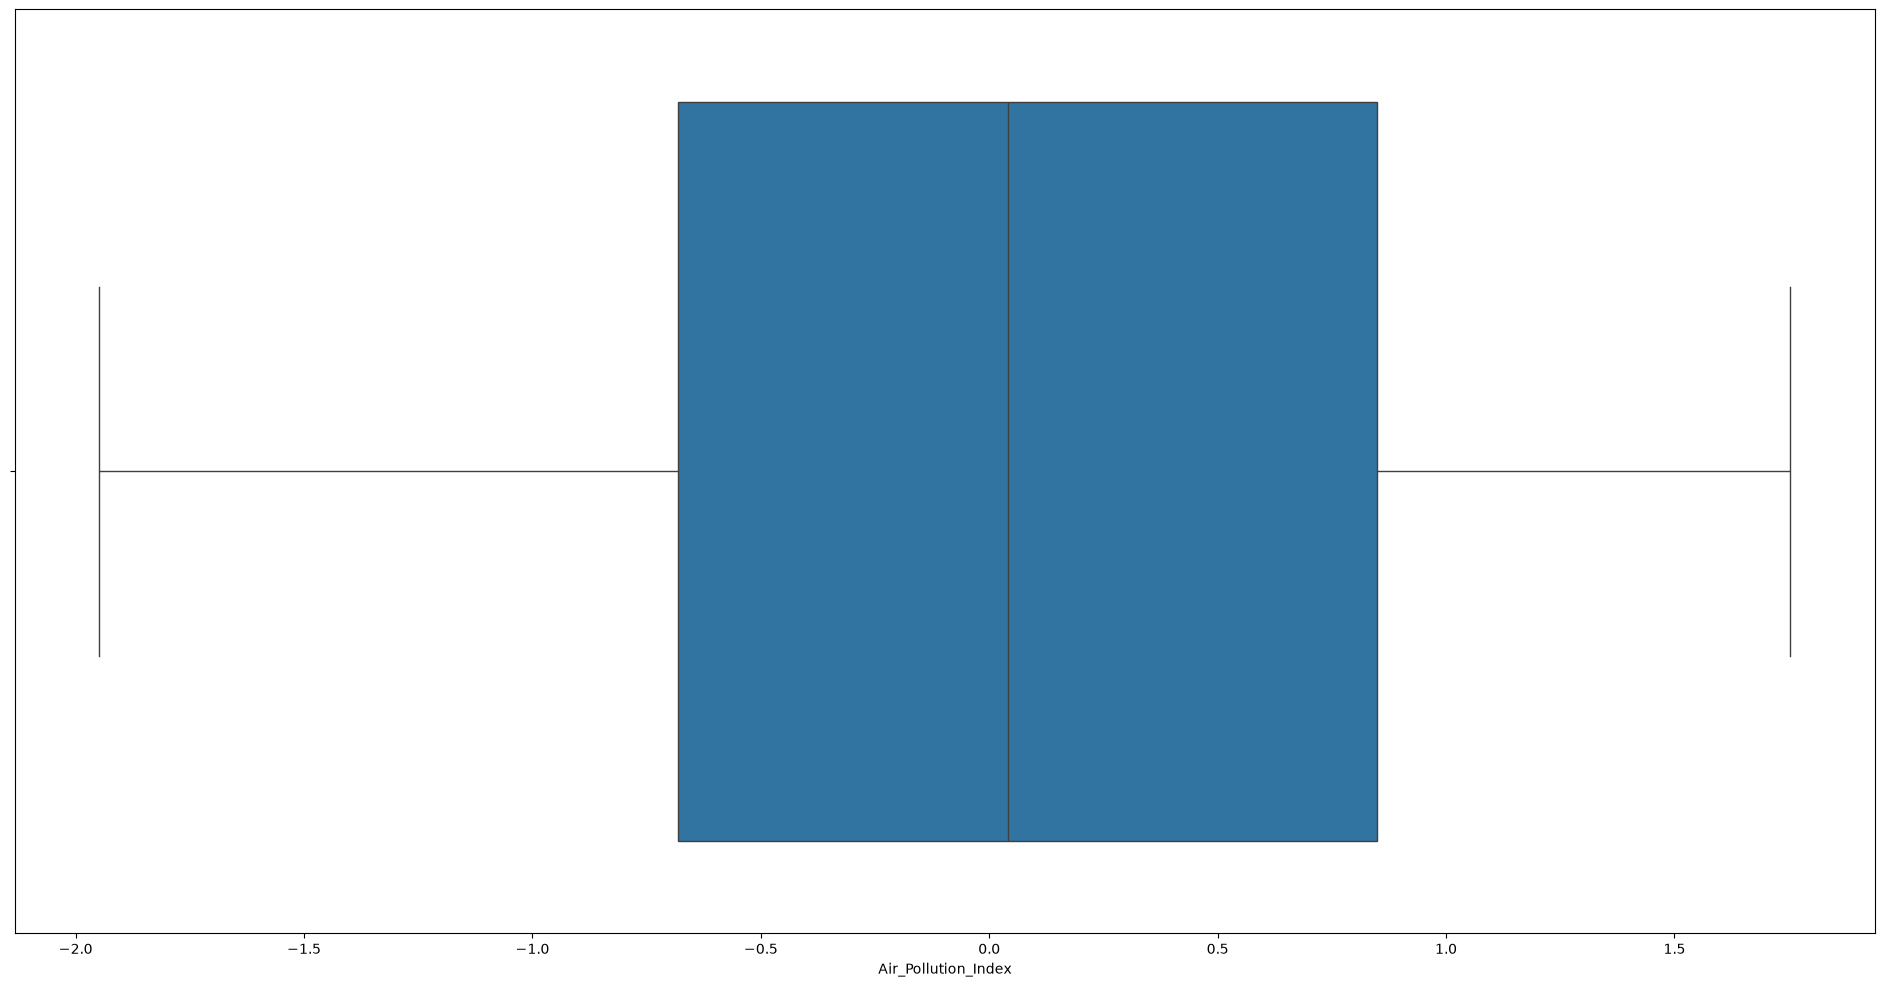

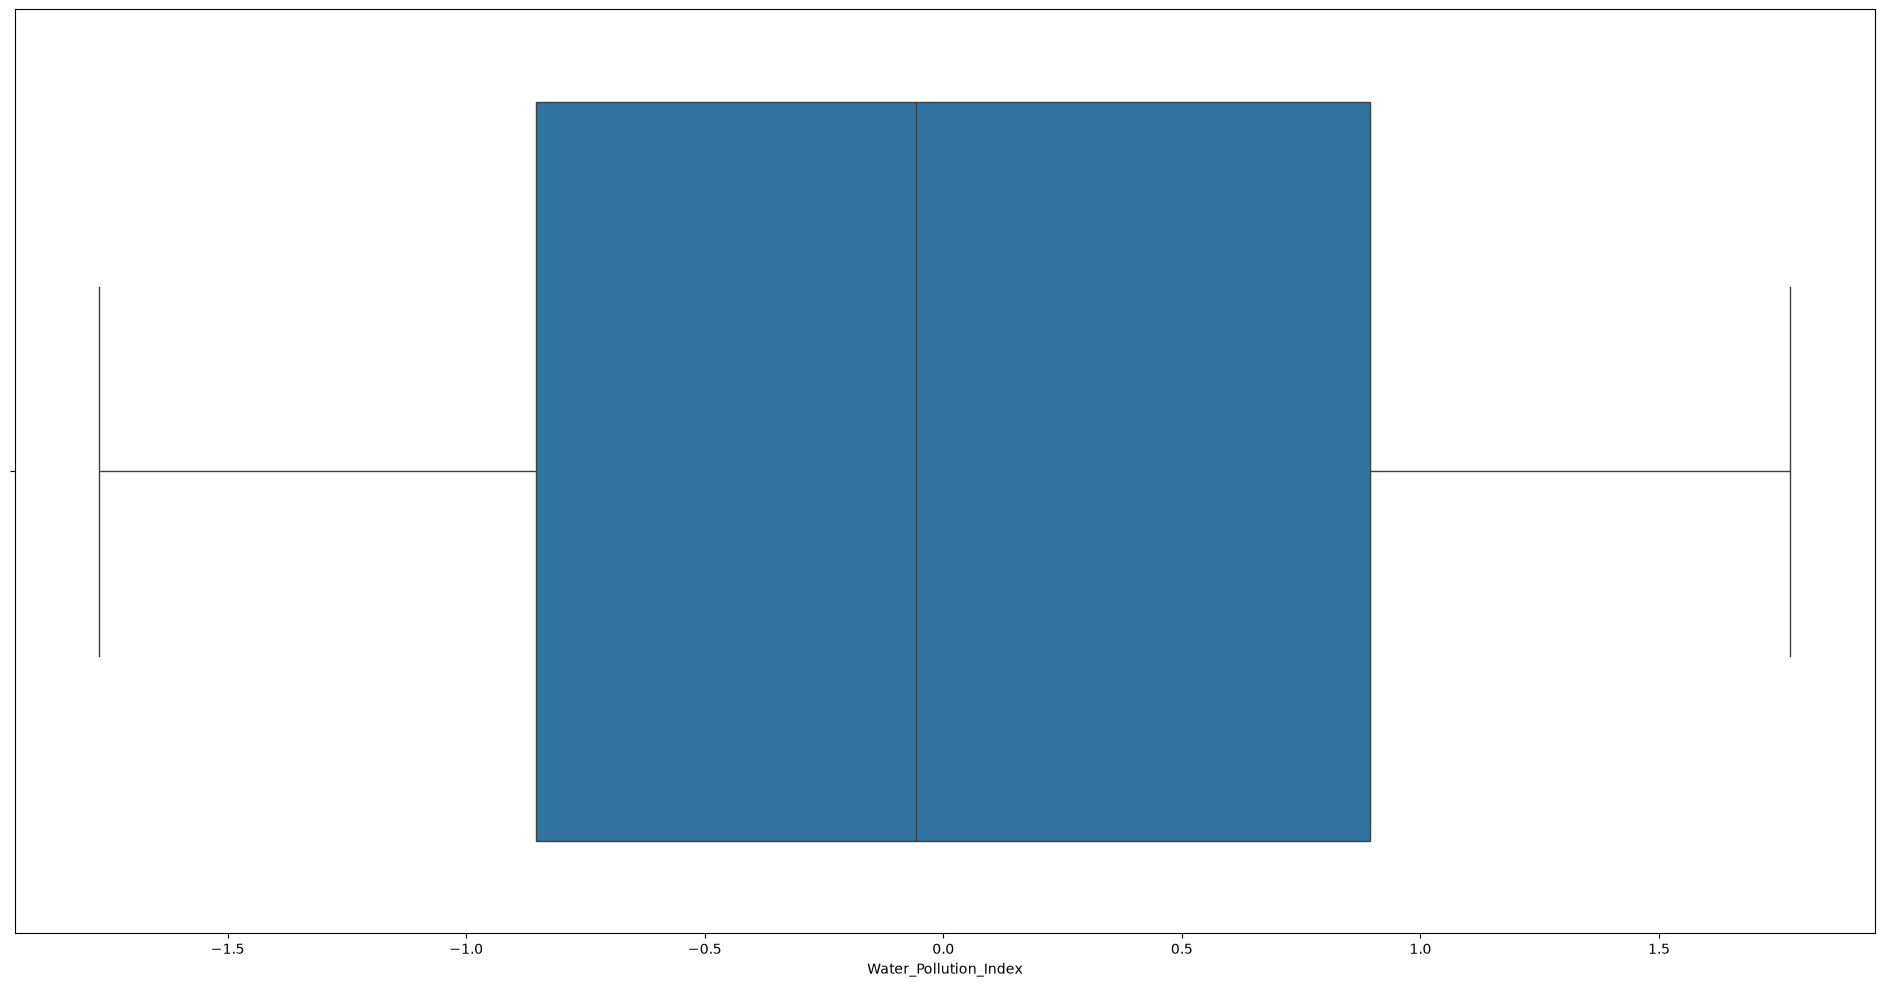

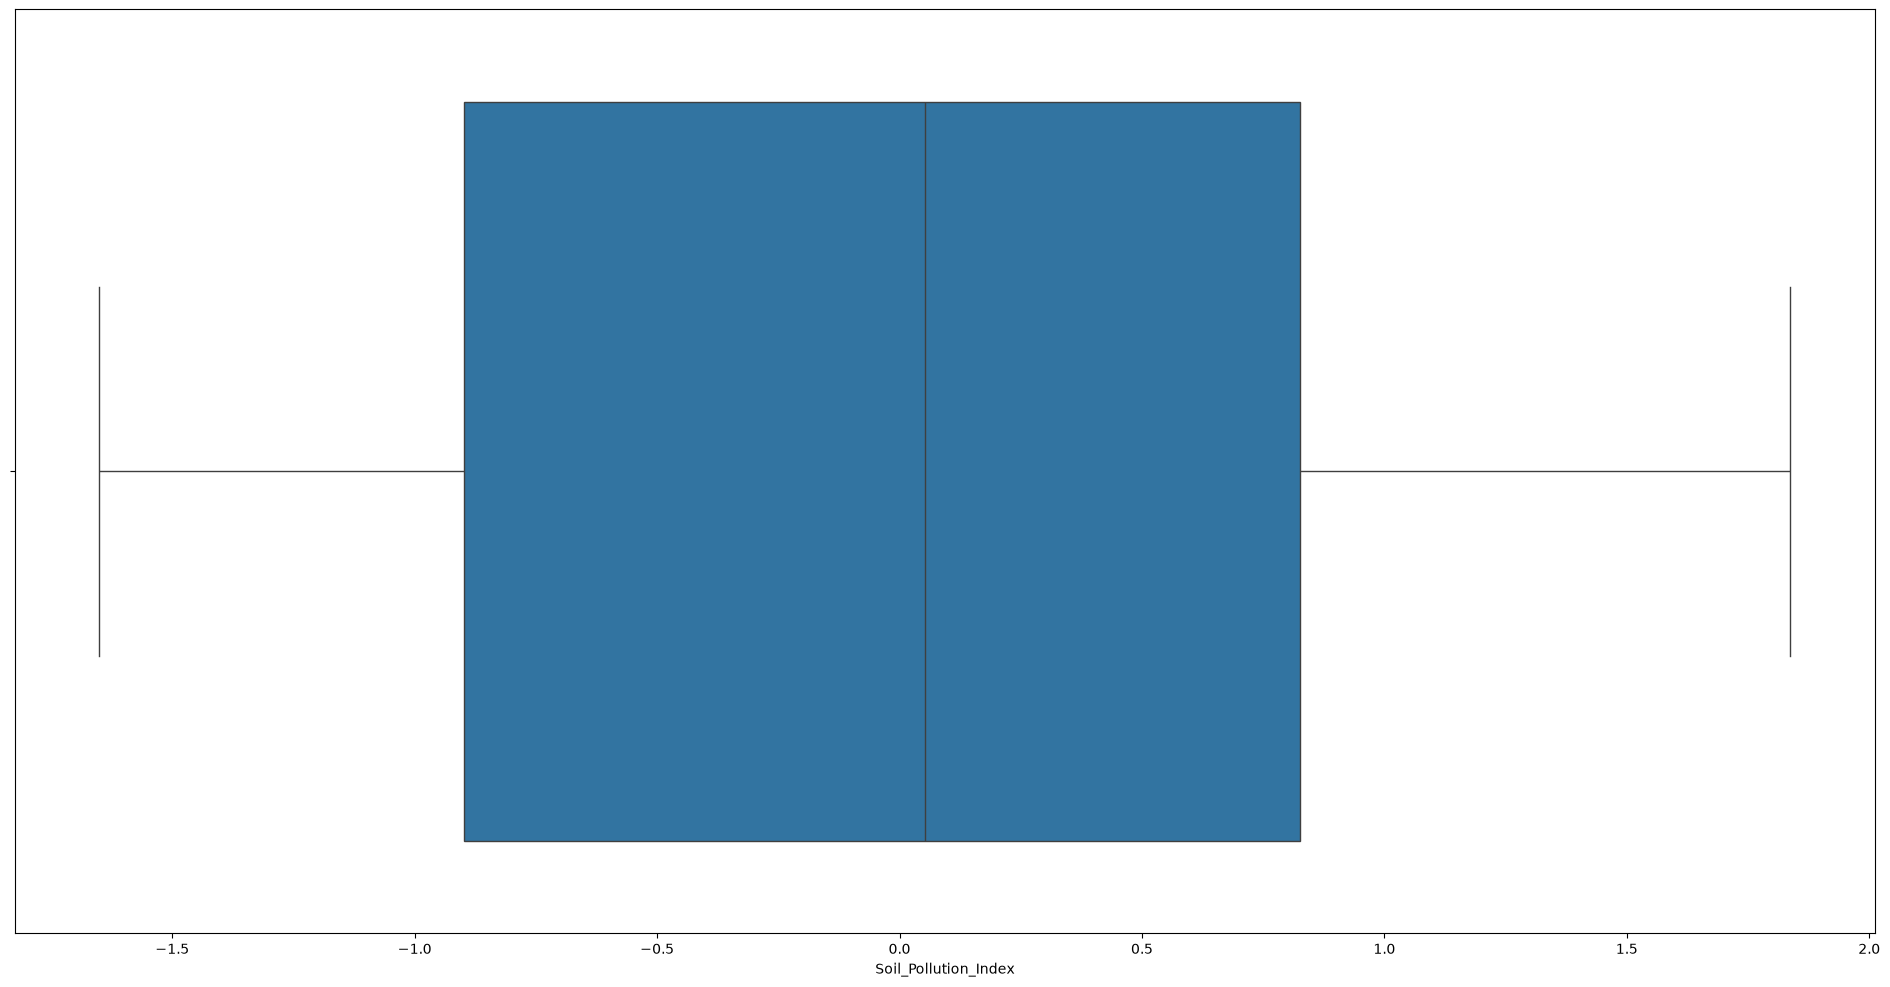

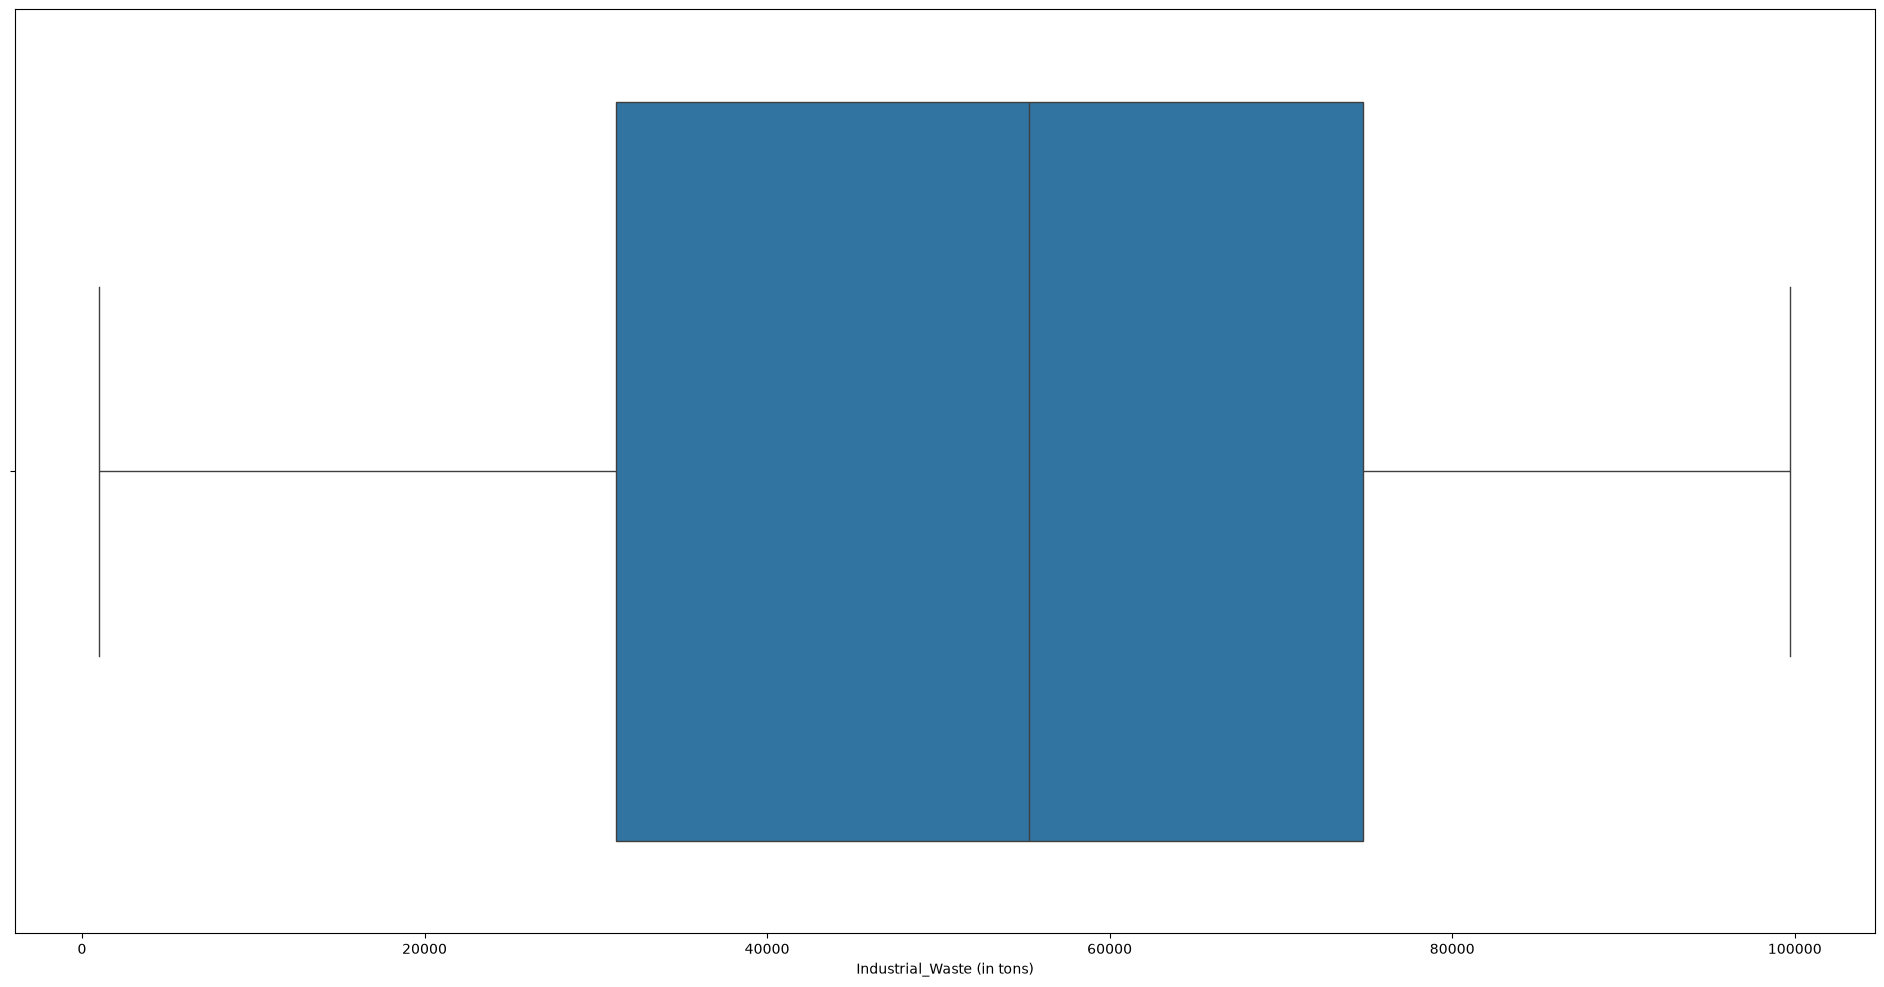

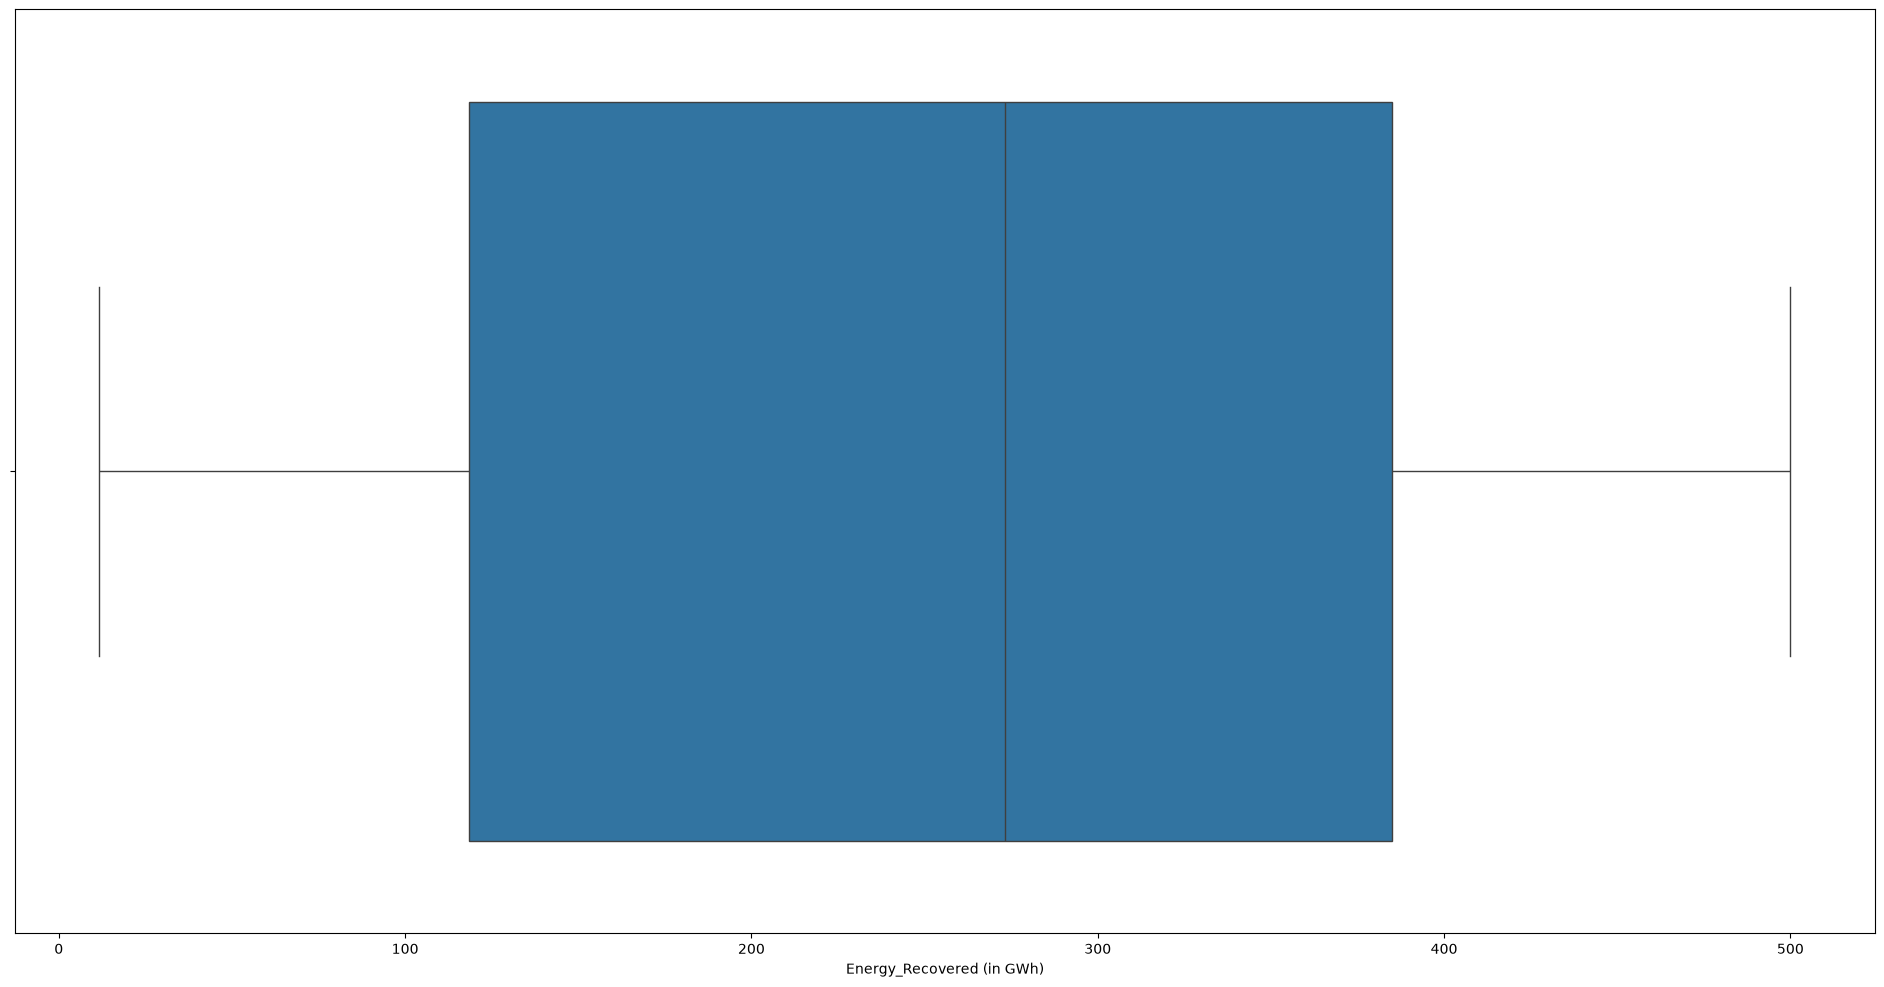

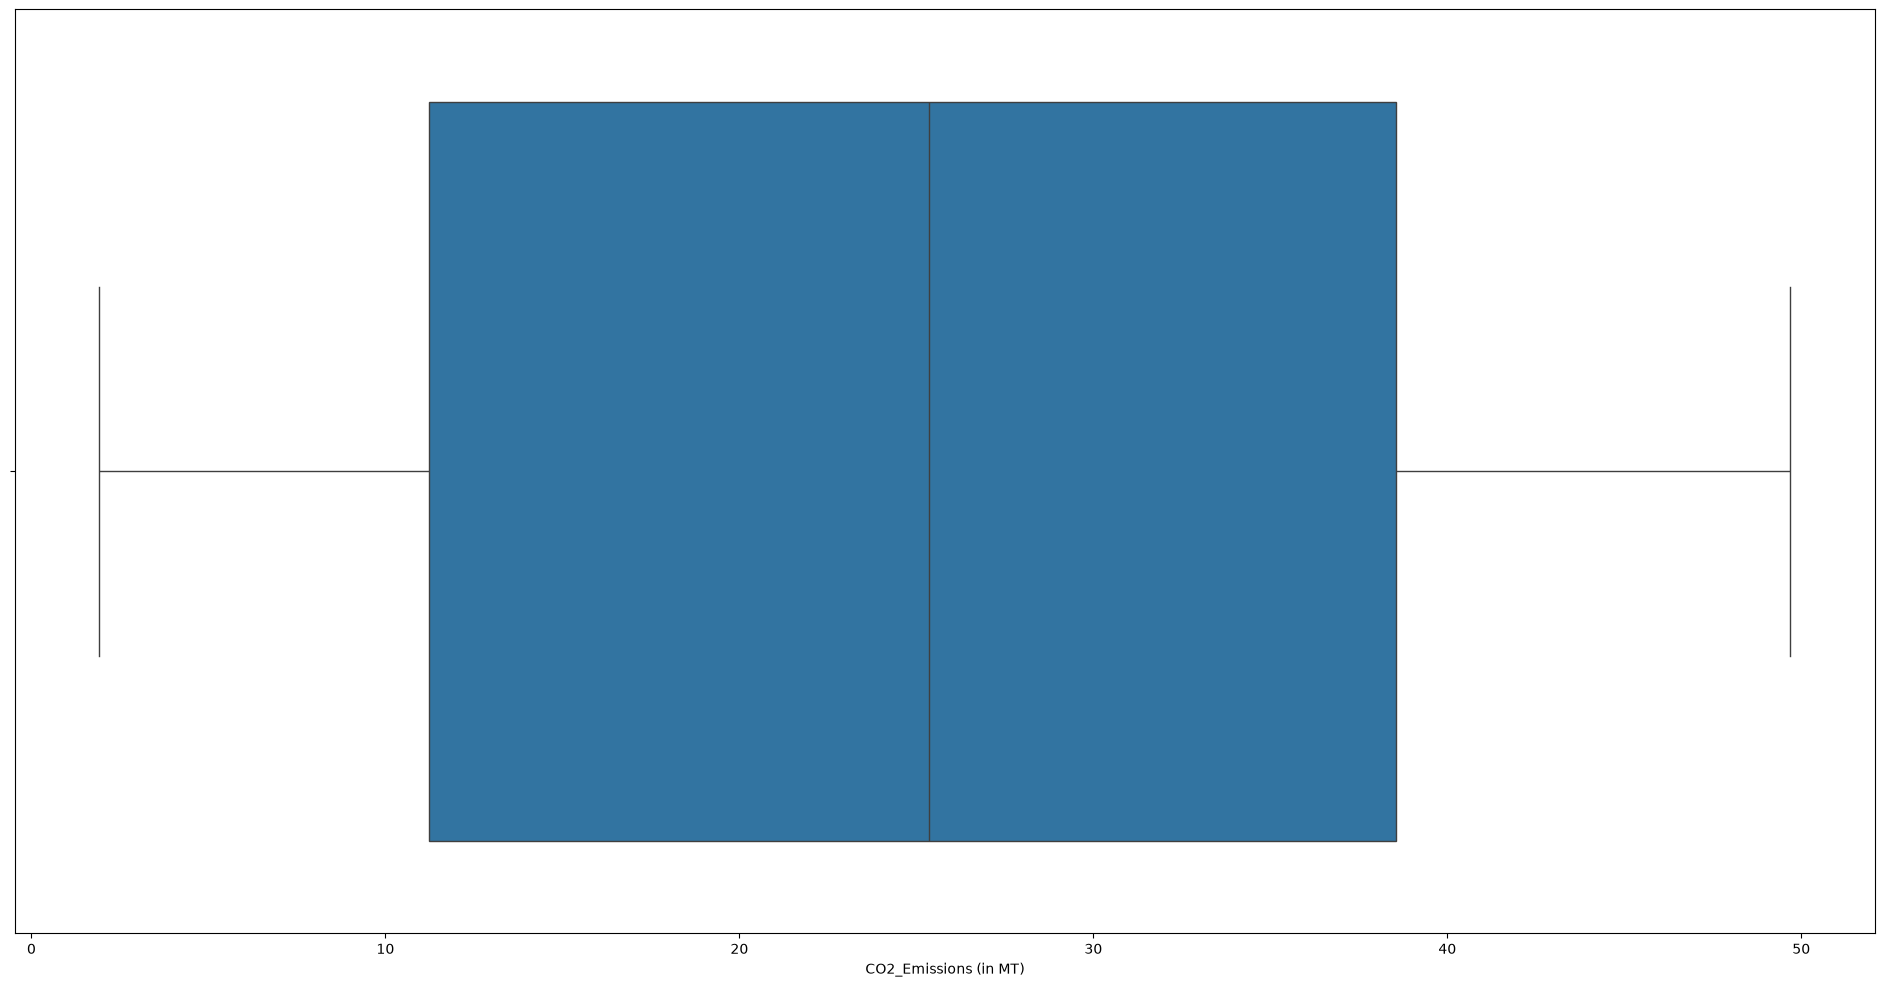

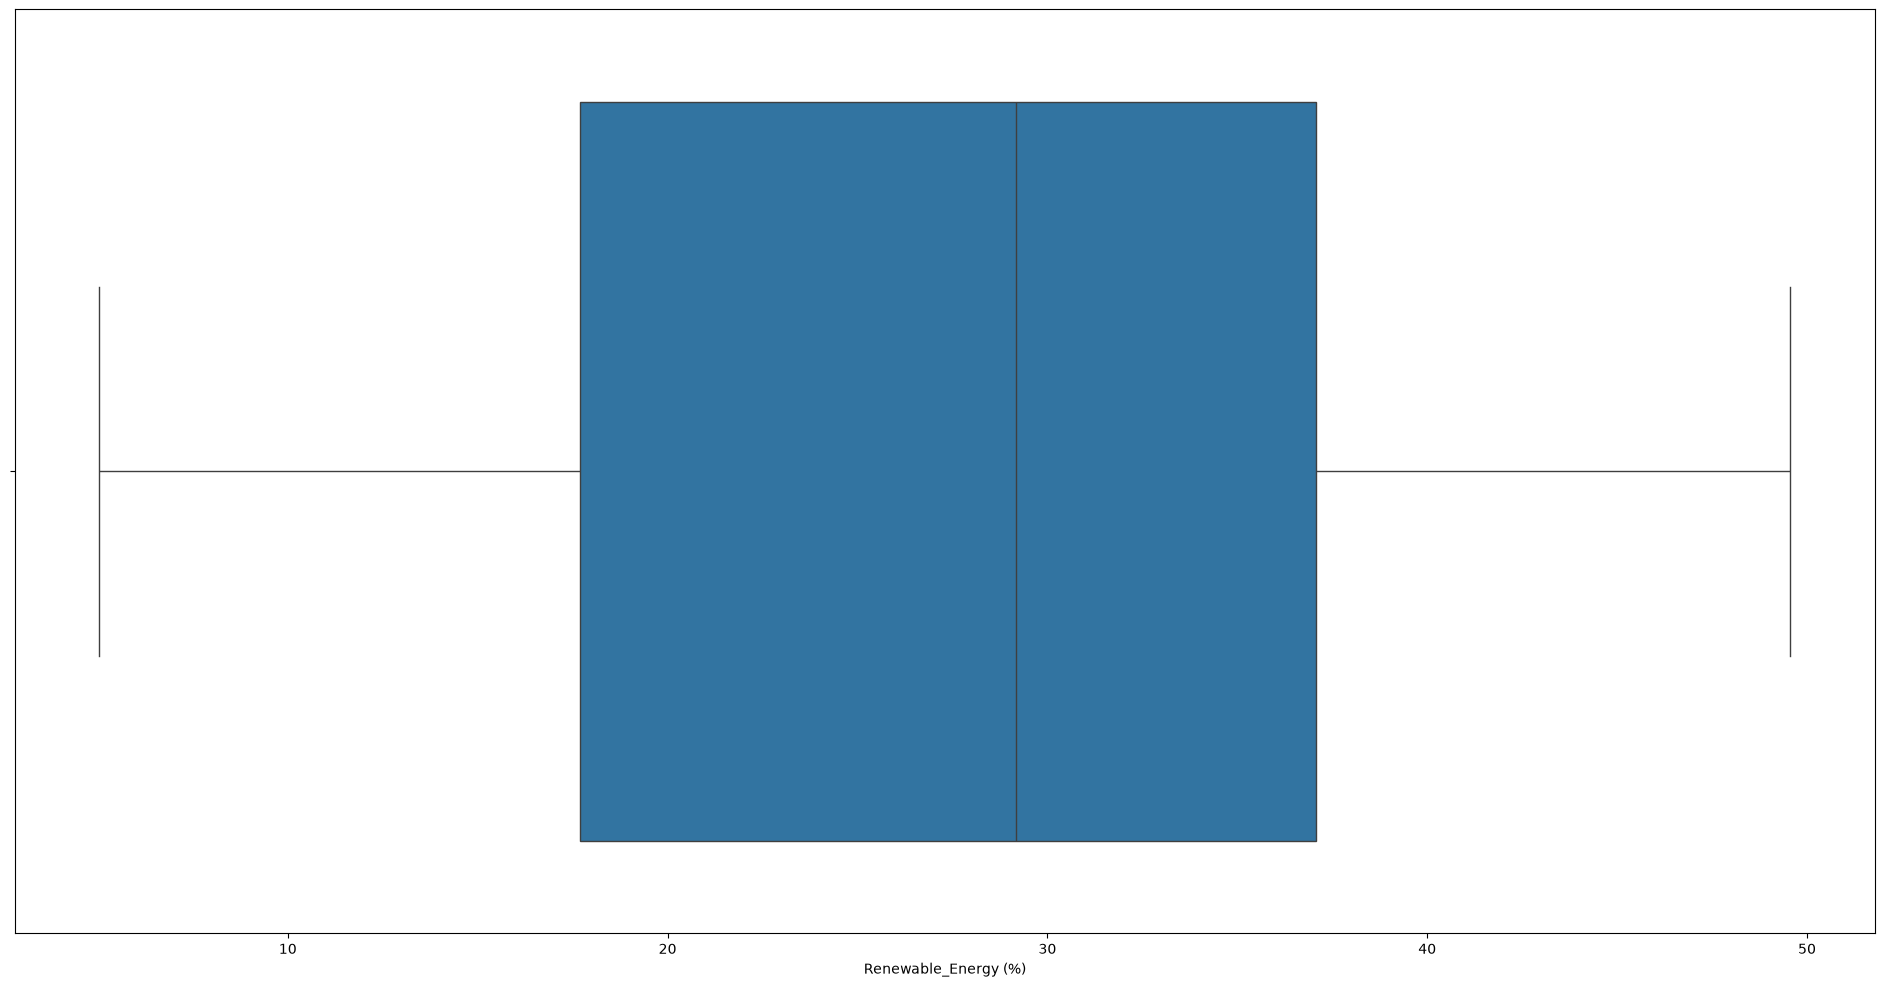

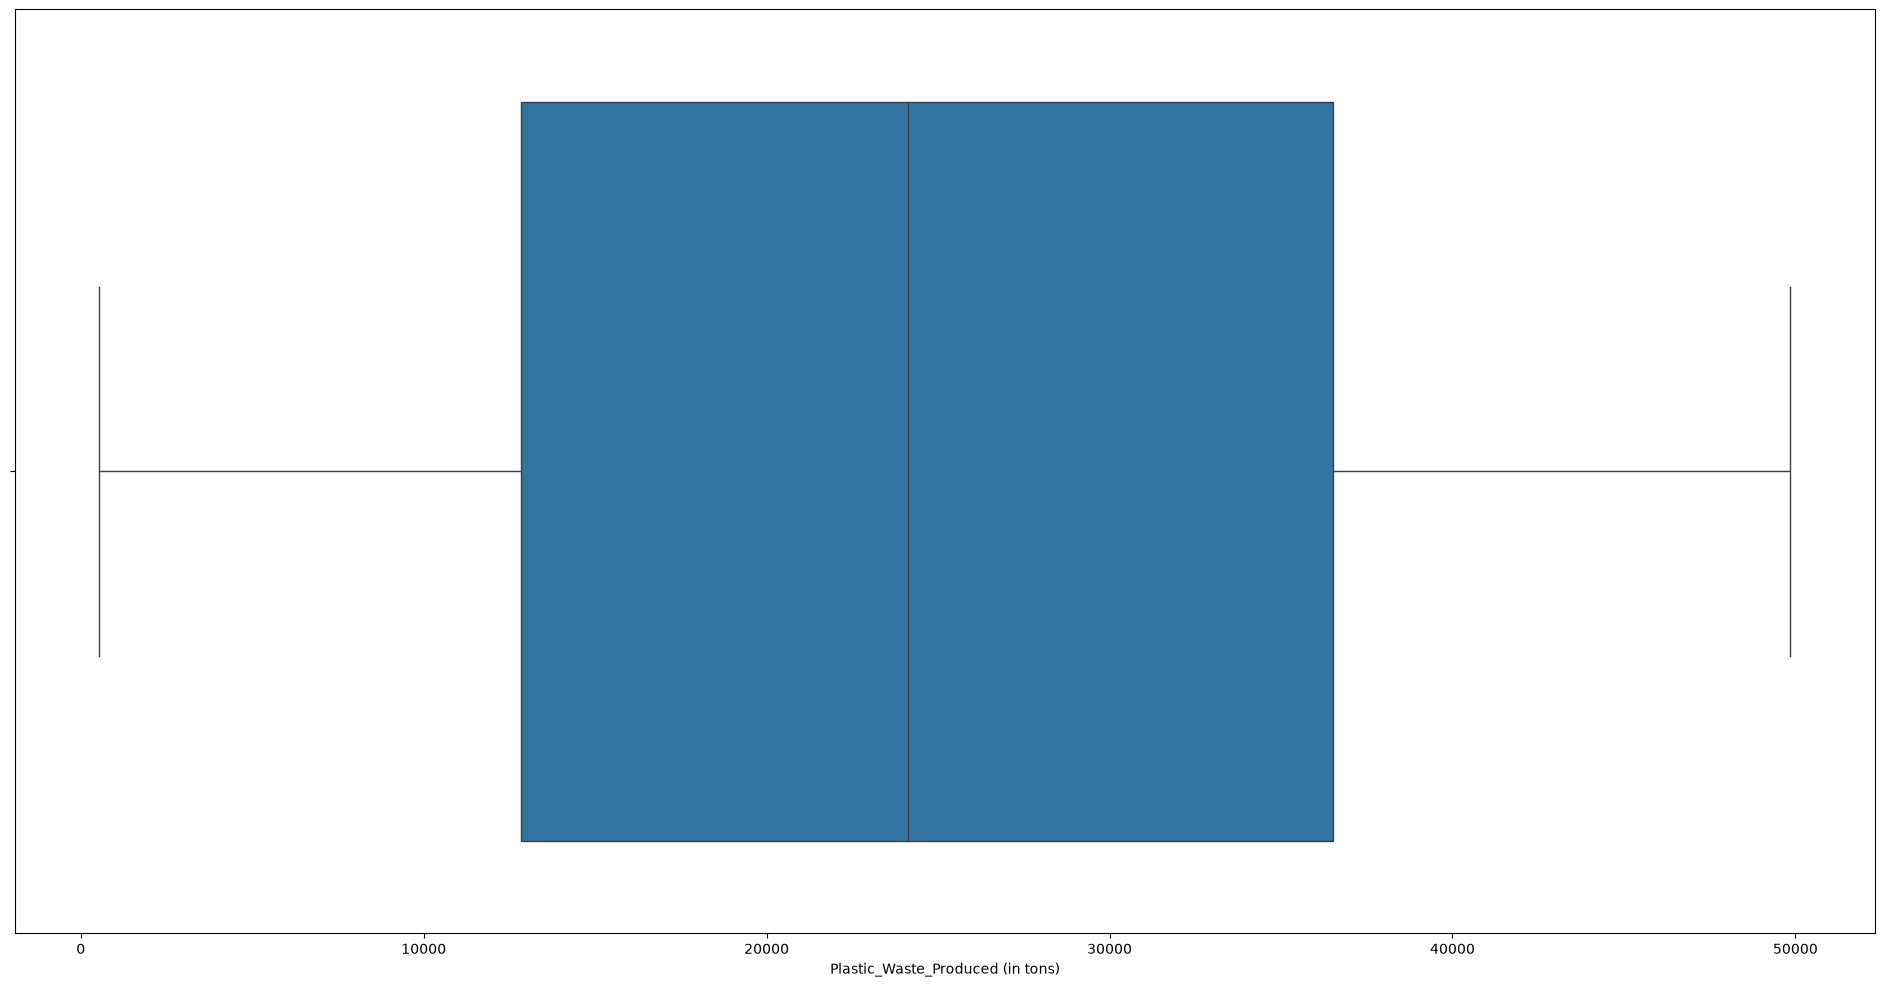

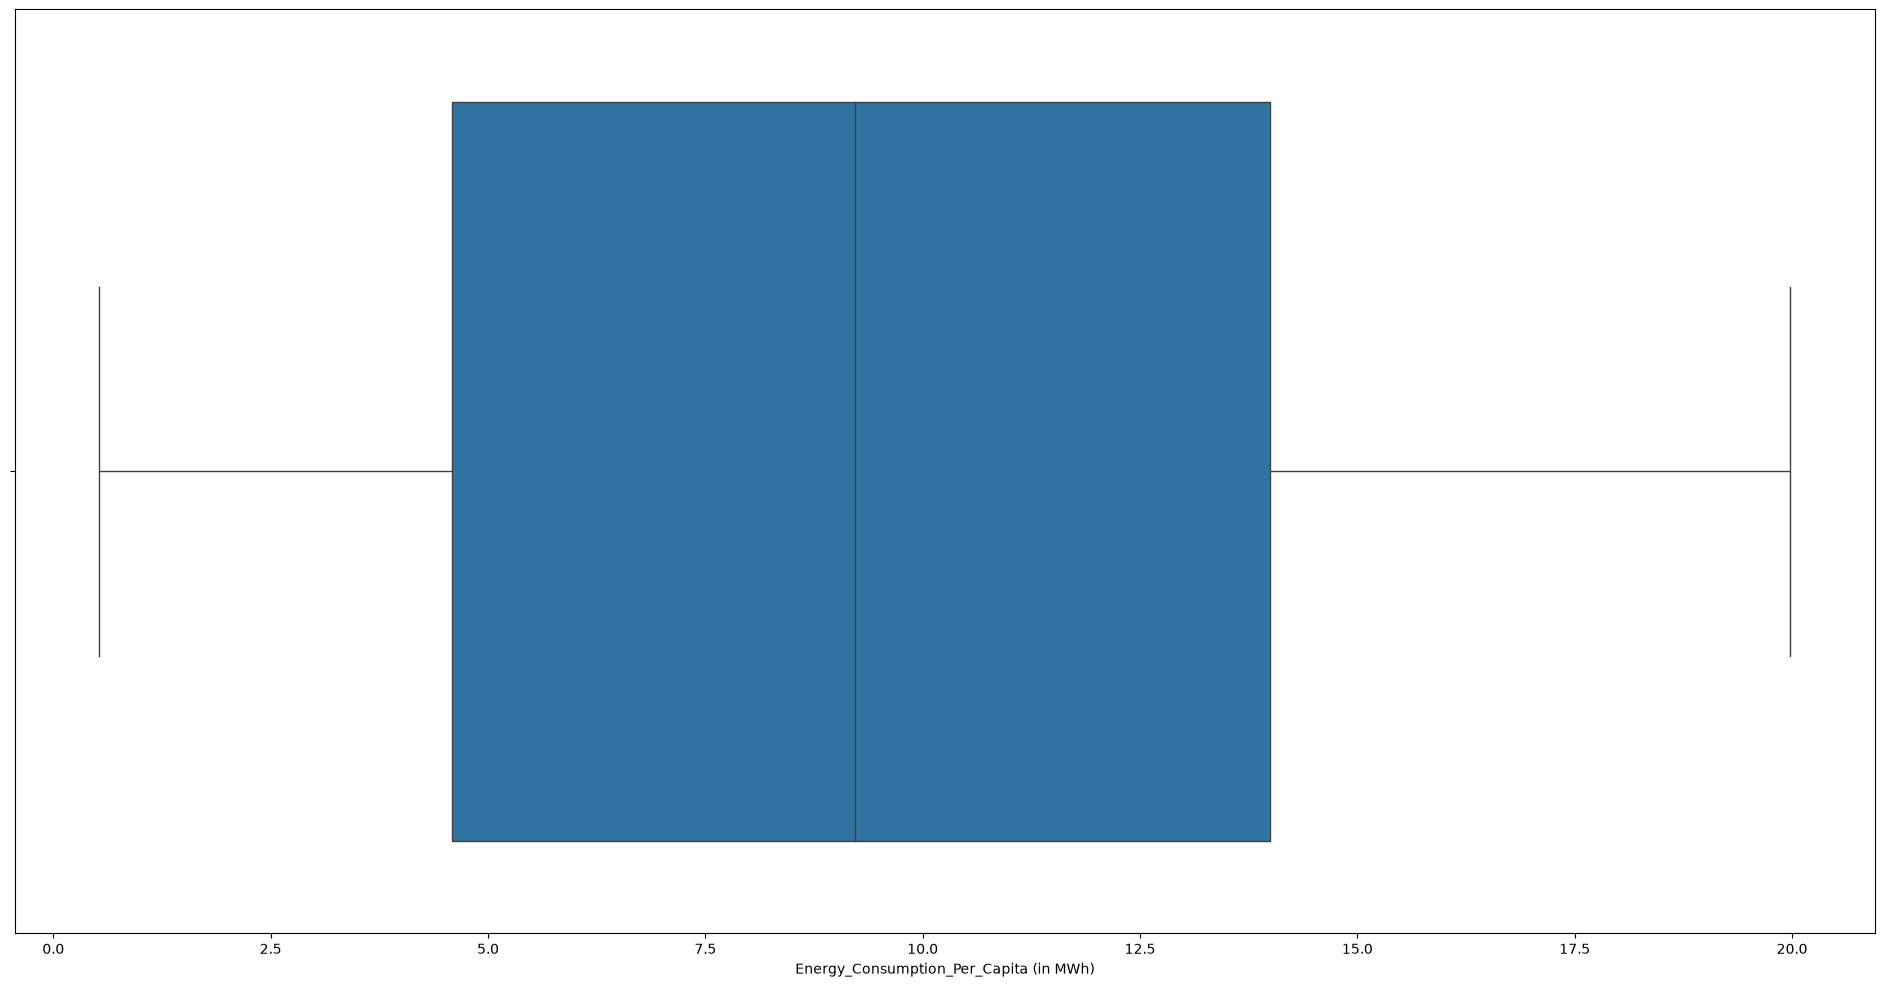

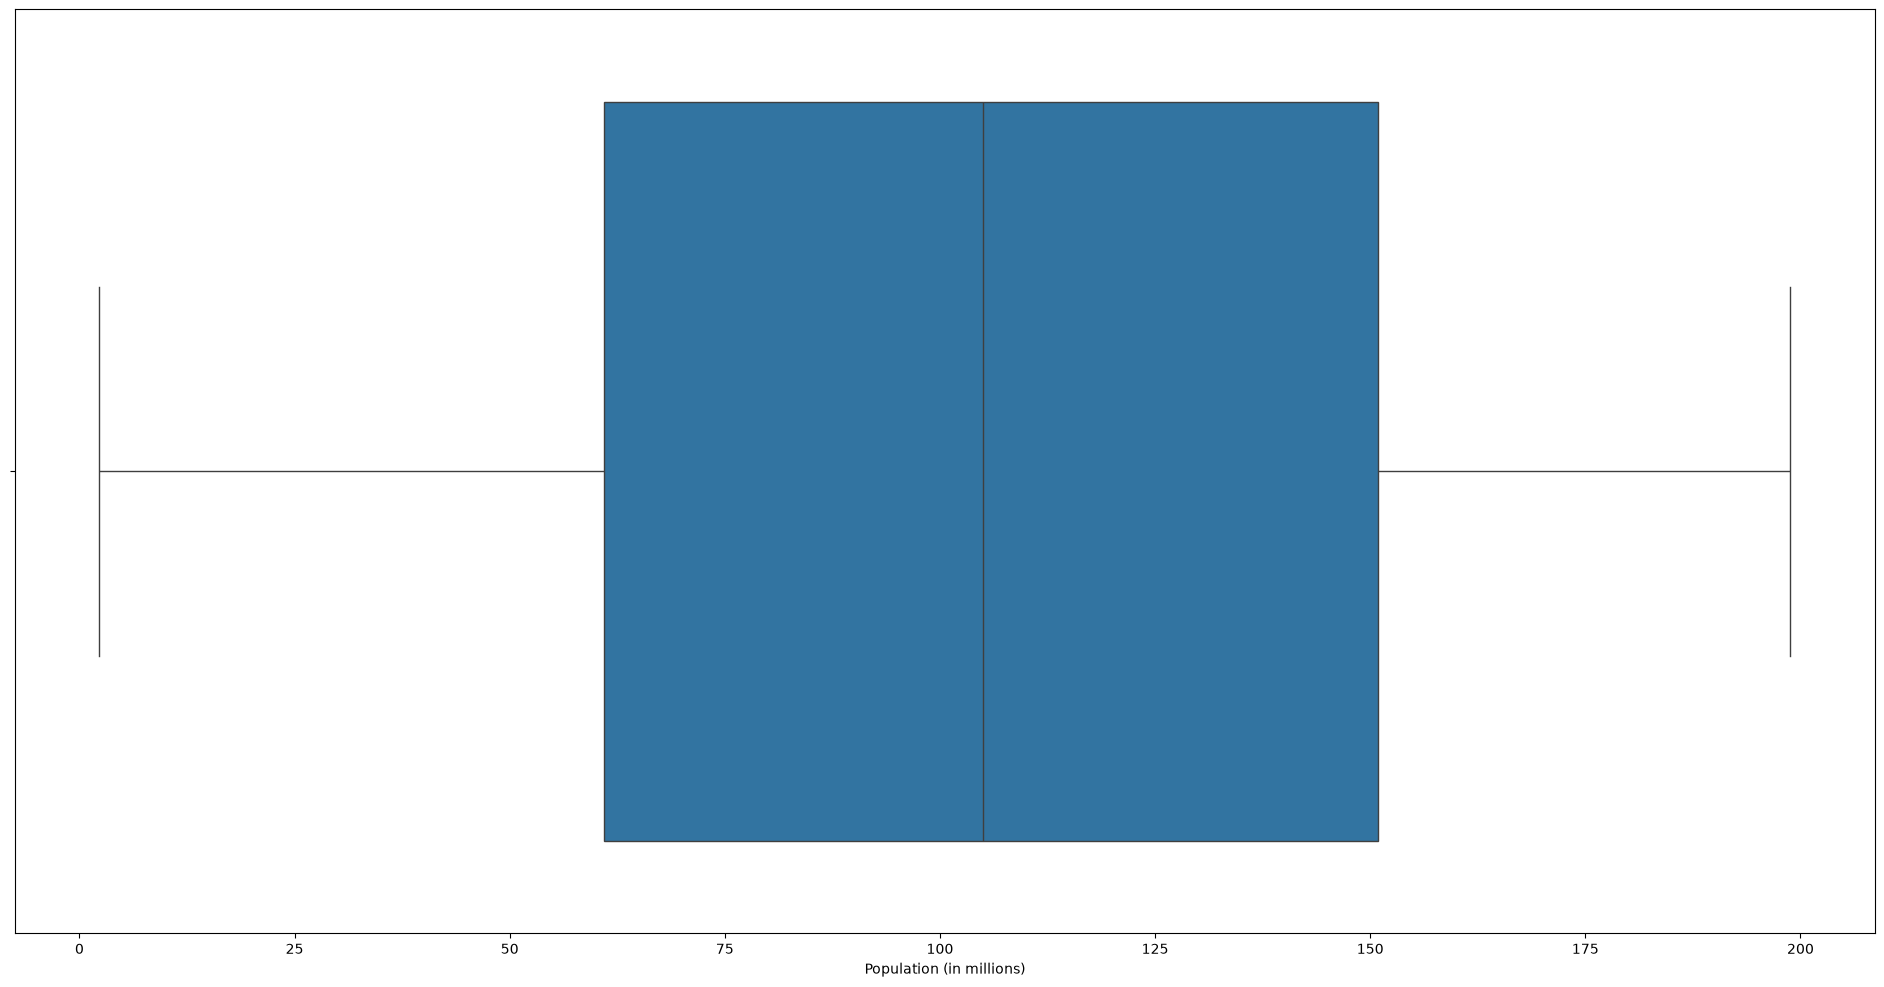

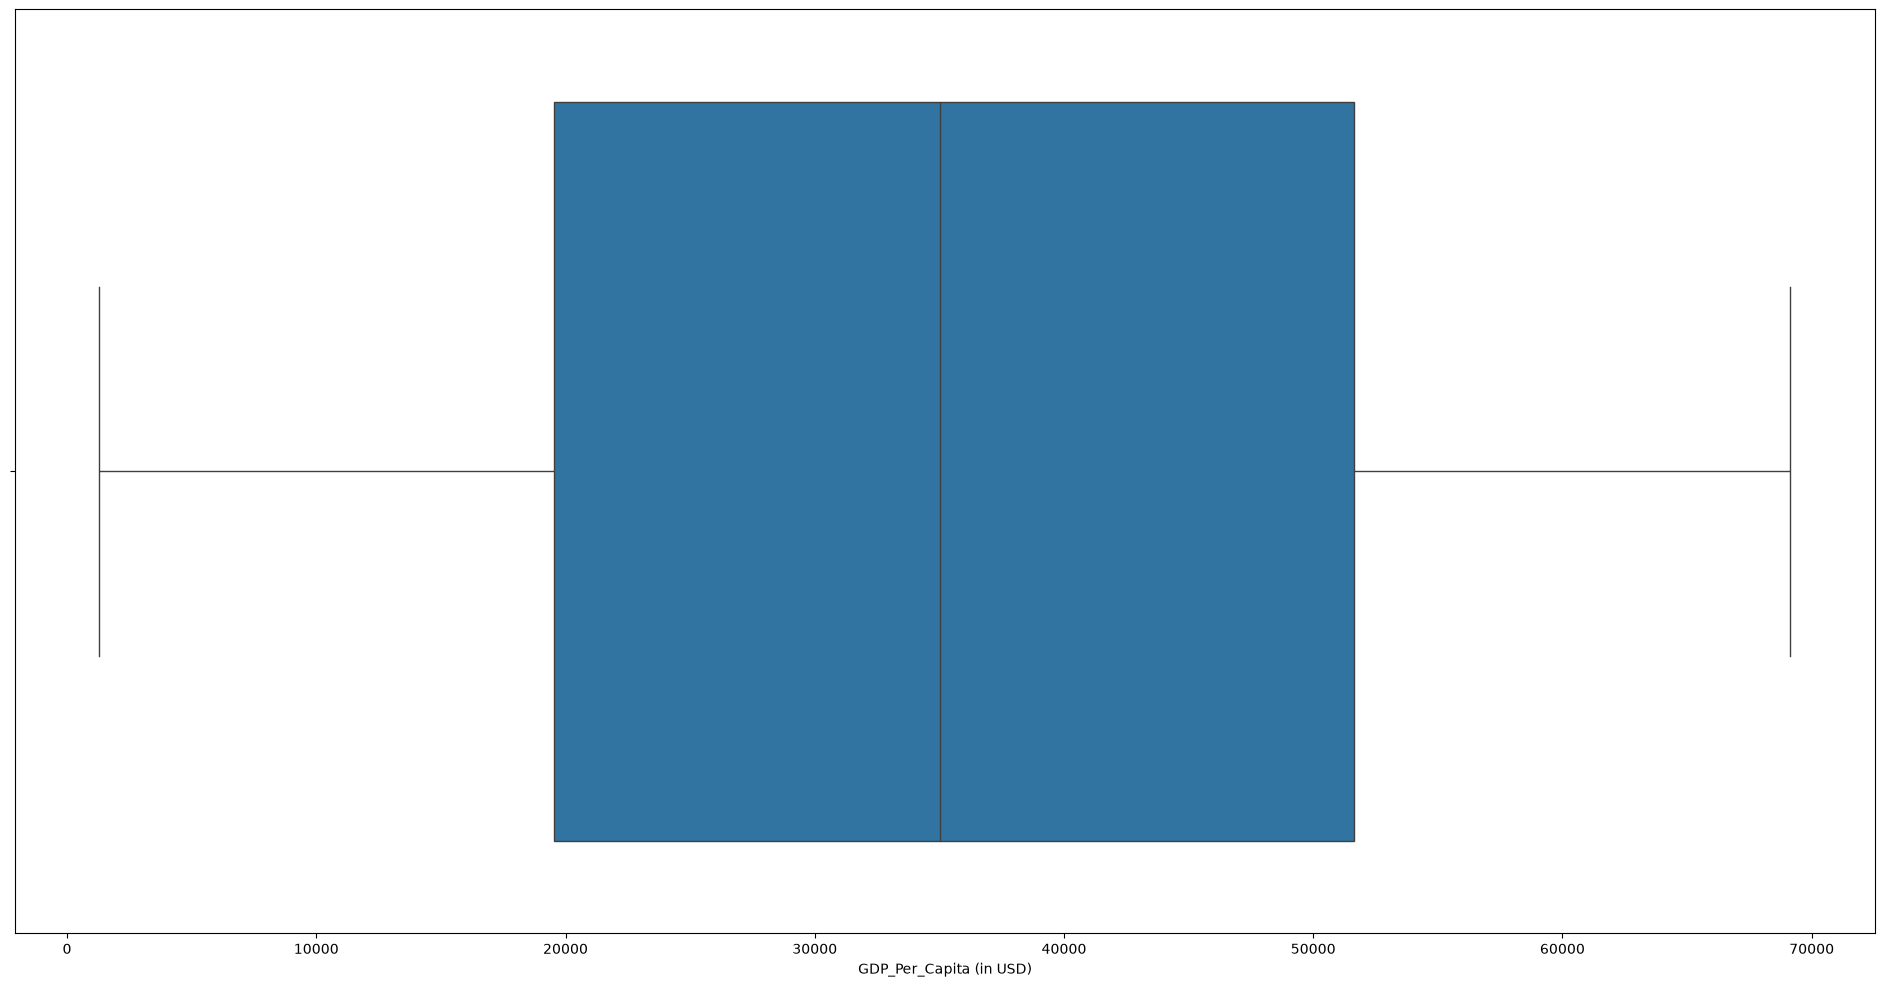

In [53]:
numeric_columns = df_new.select_dtypes(include='number').columns
for num_cols in numeric_columns:
    plt.figure(figsize=(24,12))
    sns.boxplot(x = df_new[num_cols] )

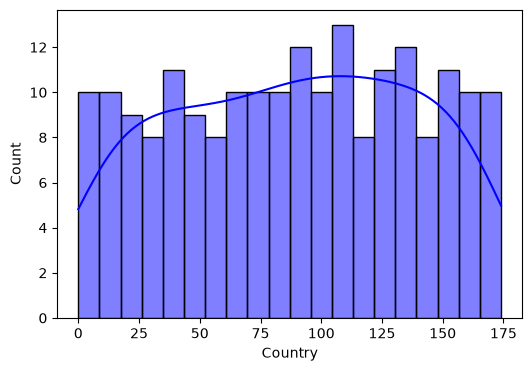

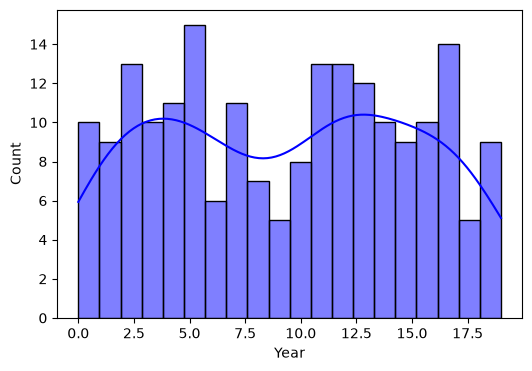

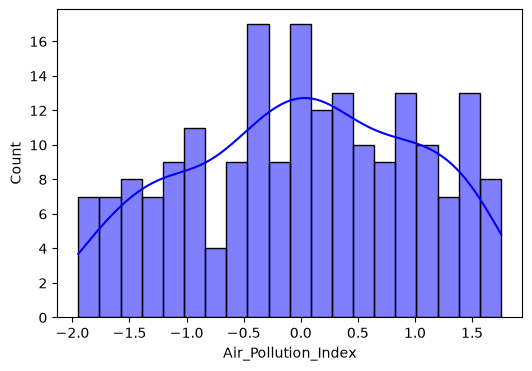

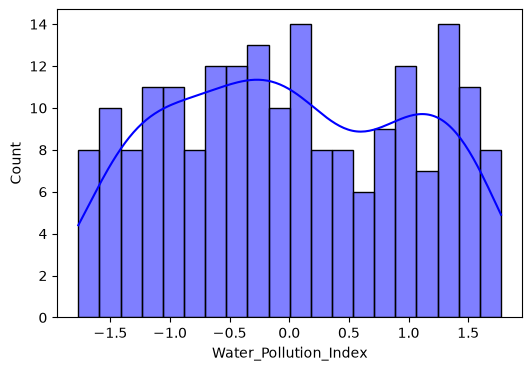

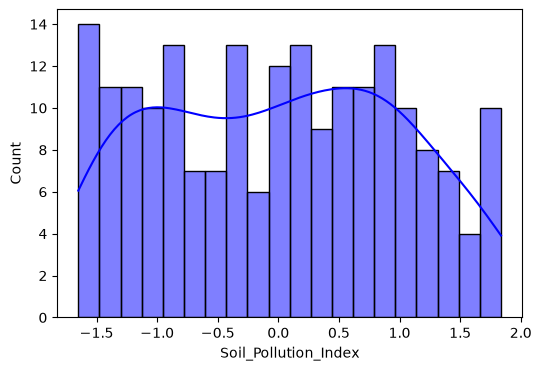

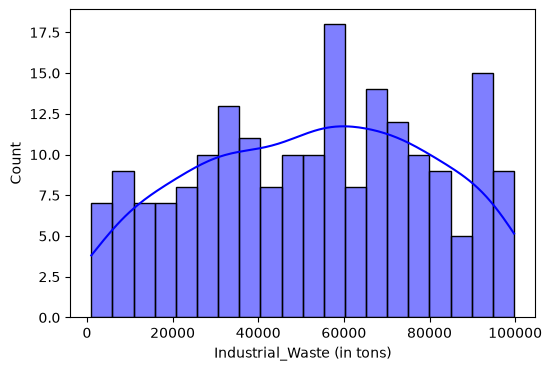

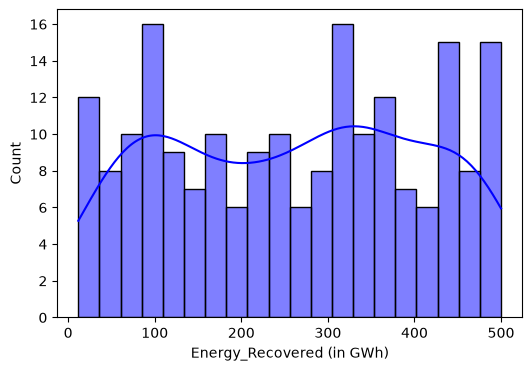

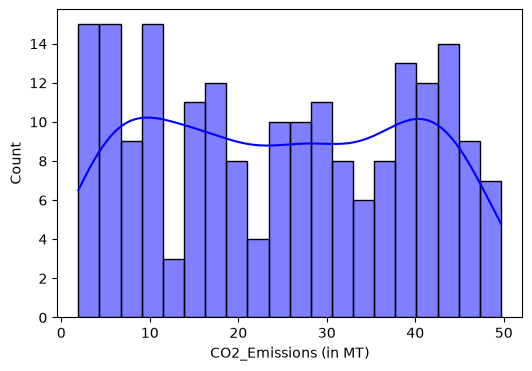

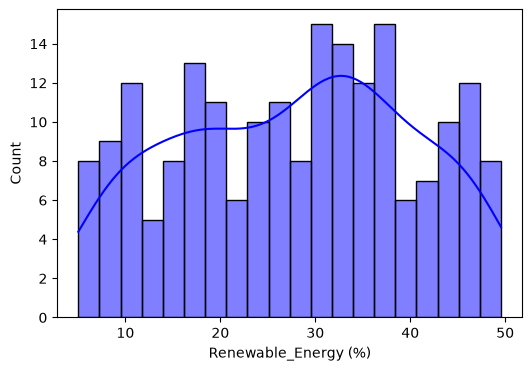

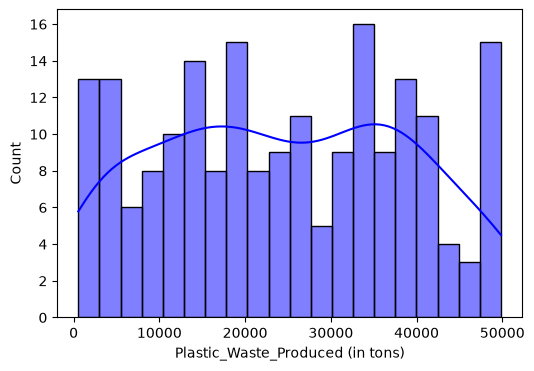

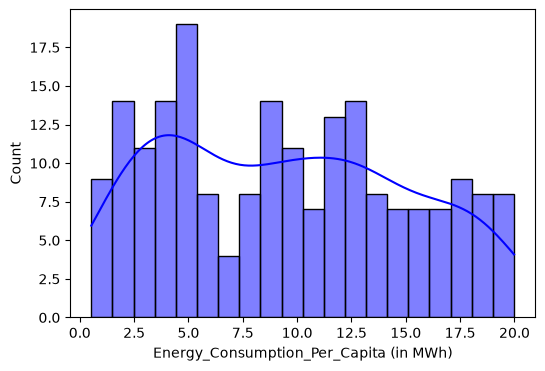

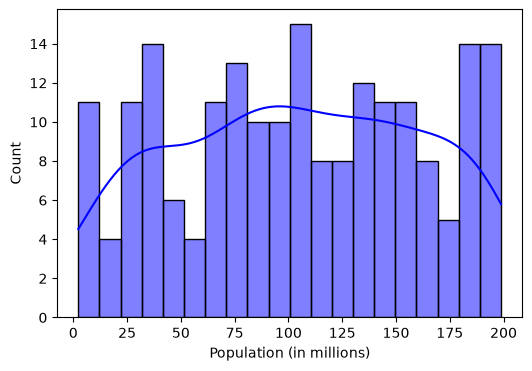

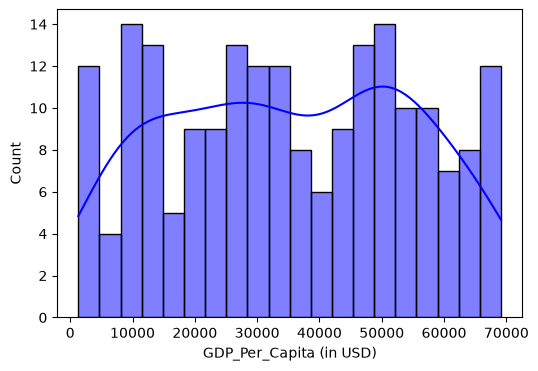

In [54]:
for num_cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df_new[num_cols] ,kde = True,bins = 20 , color="blue"  )

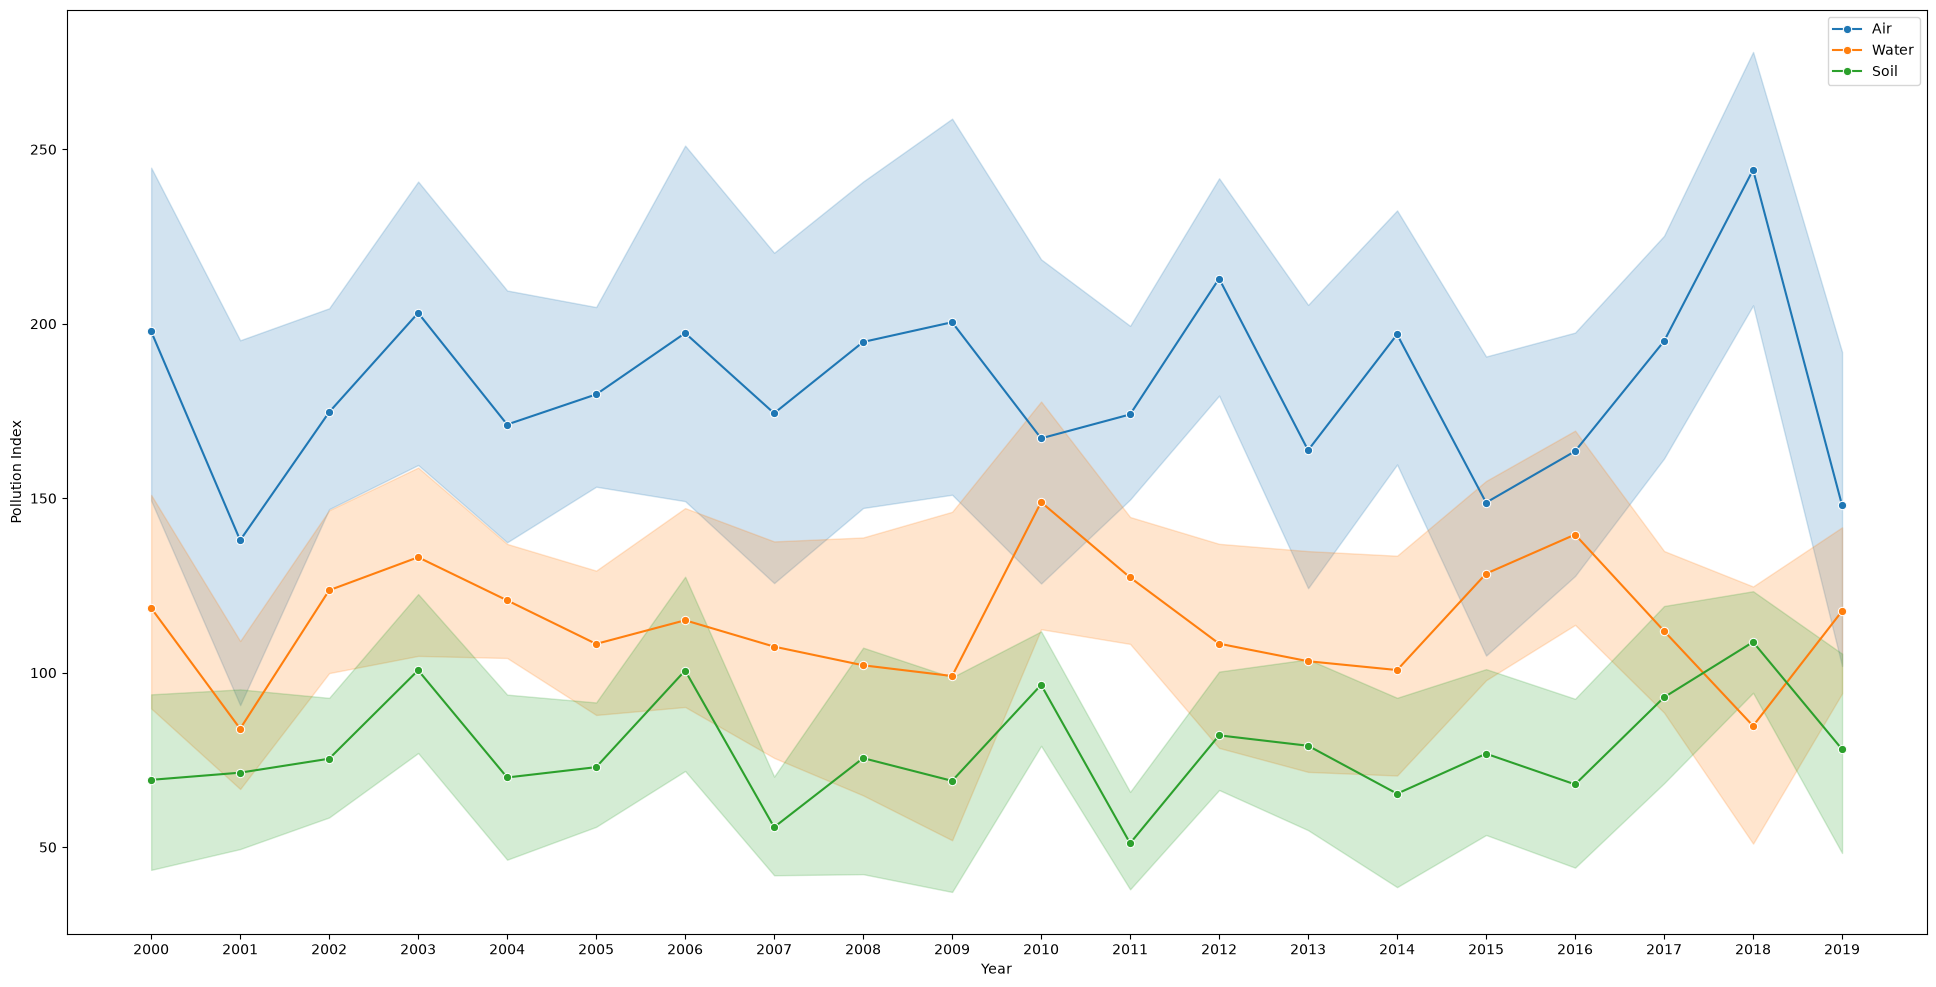

In [55]:
plt.figure(figsize=(24,12))

sns.lineplot(data=df,x='Year',y='Air_Pollution_Index',label='Air', marker='o')
sns.lineplot(data=df,x='Year',y='Water_Pollution_Index',label='Water', marker= 'o')
sns.lineplot(data=df,x='Year',y='Soil_Pollution_Index',label='Soil', marker ="o")

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Pollution Index")

plt.legend()
plt.show()

### Observation we get :
- Air Pollution (Blue Line): Generally fluctuating more, major peaks around 2003, 2006, 2009, 2012, and a maximum overall peak in 2018.

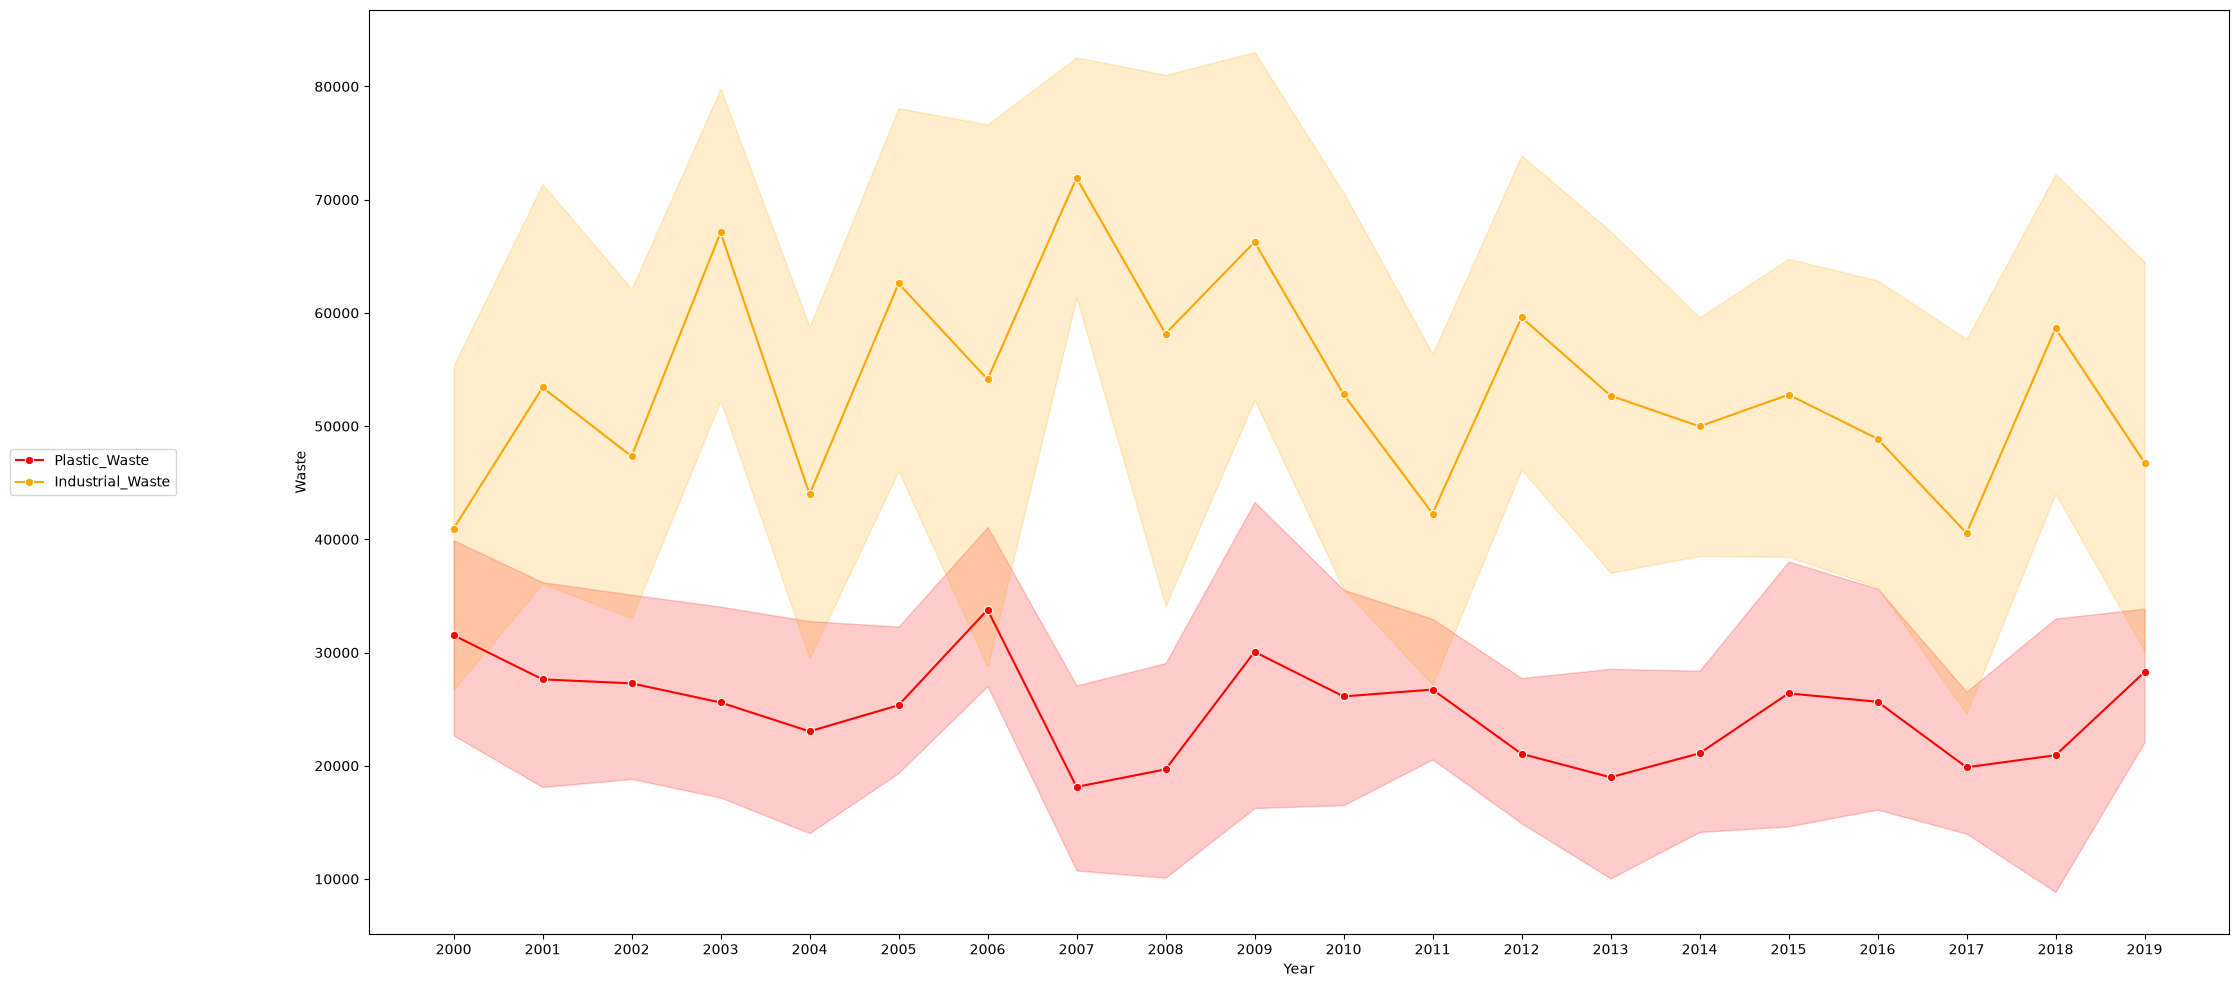

In [56]:
plt.figure(figsize=(24,12))


sns.lineplot(data=df,x='Year',y='Plastic_Waste_Produced (in tons)',label='Plastic_Waste', marker= 'o' , color='red')
sns.lineplot(data=df,x='Year',y='Industrial_Waste (in tons)',label='Industrial_Waste', marker ="o", color='orange')

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Waste")

plt.legend(loc='center right', bbox_to_anchor=(-0.1, 0.5))
plt.show()


### Industrial Waste (Orange Line): Consistently remains significantly higher than plastic waste, fluctuating between roughly 40,000 and 72,000 units.

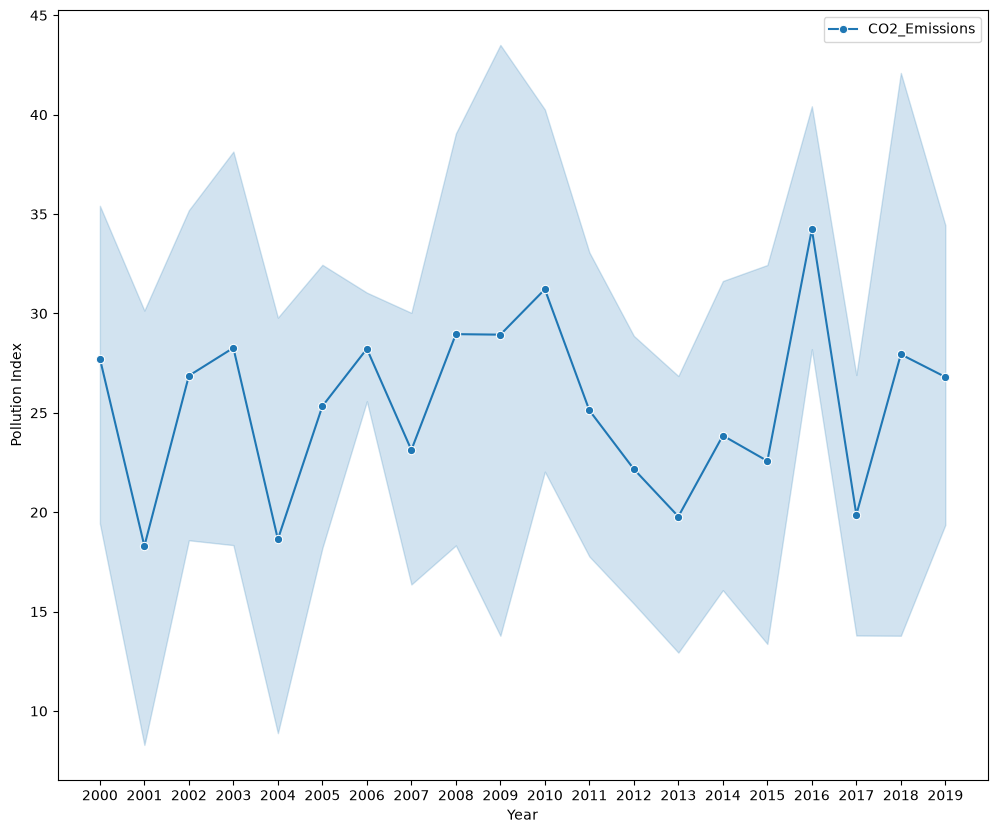

In [57]:
plt.figure(figsize=(12,10))

sns.lineplot(data=df,x='Year',y='CO2_Emissions (in MT)',label='CO2_Emissions', marker='o')

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Pollution Index")

plt.legend()
plt.show()

### Values: $\text{CO}_2$ emissions fluctuate mostly between 18 and 34 units across the 20-year period.

In [58]:
df['Average_Pollution'] = (
    df['Air_Pollution_Index'] +
    df['Water_Pollution_Index'] +
    df['Soil_Pollution_Index']
) / 3

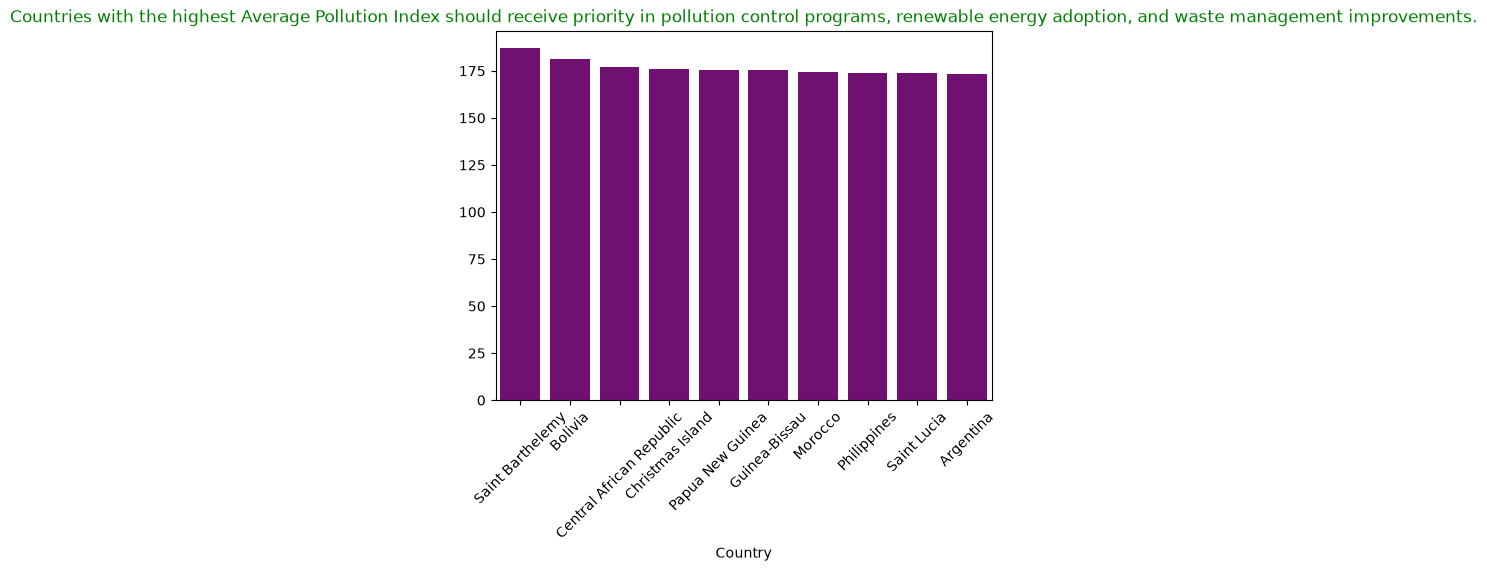

In [59]:
top10 = df.groupby('Country')['Average_Pollution'].mean().sort_values(ascending=False).head(10) # take help here :)

sns.barplot(x=top10.index, y=top10.values , color='purple')
plt.xticks(rotation=45)
plt.title("Countries with the highest Average Pollution Index should receive priority in pollution control programs, renewable energy adoption, and waste management improvements.", color="green")
plt.show()

Step 3 - Feature Engineering

In [60]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Average_Pollution
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667


In [61]:
yearly_trends = df.groupby("Year" , as_index=False)[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Average_Pollution",
    "Energy_Recovered (in GWh)"
]].mean()

yearly_trends.head()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Average_Pollution,Energy_Recovered (in GWh)
0,2000,197.796000,118.513000,69.283000,128.530667,296.889000
1,2001,137.964444,83.933333,71.340000,97.745926,288.877778
2,2002,174.661538,123.617692,75.344615,124.541282,259.750769
3,2003,203.103000,133.080000,100.687000,145.623333,208.139000
4,2004,171.120909,120.719091,69.959091,120.599697,186.458182


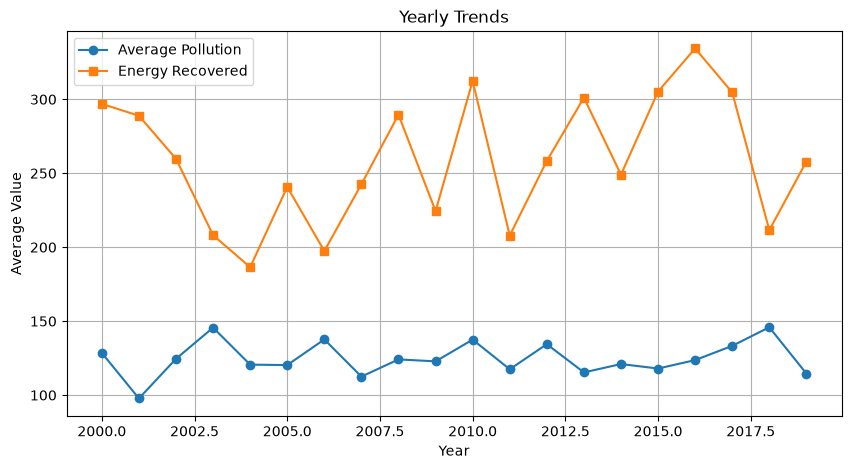

In [62]:
plt.figure(figsize=(10,5))
plt.plot(yearly_trends["Year"],
         yearly_trends["Average_Pollution"],
         marker='o',
         label="Average Pollution")

plt.plot(yearly_trends["Year"],
         yearly_trends["Energy_Recovered (in GWh)"],
         marker='s',
         label="Energy Recovered")

plt.xlabel("Year")
plt.ylabel("Average Value")
plt.title("Yearly Trends")
plt.legend()
plt.grid(True)

plt.show()

Energy_Consumption_Per_Capita (in MWh) is already given in the features , so no feature extraction

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [64]:
 
df["Pollution_Severity"] = pd.cut( 
    df["Average_Pollution"],
    bins=[0, 100, 170, float("inf")],
    labels=["Low", "Medium", "High"]
)

df["Pollution_Severity"].value_counts()

Pollution_Severity
Medium    145
Low        42
High       13
Name: count, dtype: int64

In [65]:
df.head(12)

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Average_Pollution,Pollution_Severity
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000,Medium
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333,Low
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000,Low
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667,Medium
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667,Medium
5,Croatia,2009,151.36,61.07,86.75,58079.80,136.26,33.39,39.49,12191.70,18.14,103.43,35092.93,99.726667,Low
6,Congo,2008,292.31,156.85,36.40,67774.76,199.71,35.29,26.17,9450.05,16.50,182.09,52050.07,161.853333,Medium
7,Central African Republic,2006,209.41,188.14,133.50,70552.49,499.98,29.04,47.64,26605.75,2.40,73.43,16491.90,177.016667,High
8,Swaziland,2007,269.63,62.33,71.19,43280.42,495.28,28.55,11.47,2137.98,12.42,11.26,55594.15,134.383333,Medium
9,Sri Lanka,2002,231.99,155.31,44.99,11306.14,472.63,48.35,45.31,49211.55,16.79,77.21,11627.65,144.096667,Medium


In [66]:
X = df[[
    "Air_Pollution_Index",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)",
    "Renewable_Energy (%)"
]]

y = df["Pollution_Severity"]

In [67]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [68]:
print(y)

[2 1 1 2 2 1 2 0 2 2 2 2 2 2 2 2 1 2 1 2 2 2 1 2 2 2 2 1 2 2 1 2 2 2 0 2 2
 2 2 2 2 1 1 2 2 2 1 2 2 1 2 2 2 1 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 1 2
 2 1 2 0 2 1 2 2 2 2 2 2 2 1 1 2 2 1 2 2 0 2 2 1 1 2 2 2 2 0 2 2 2 2 2 2 1
 1 2 0 2 2 2 1 2 2 2 2 2 2 2 2 2 1 2 2 2 1 2 2 2 2 0 2 2 2 2 2 2 2 1 2 1 2
 2 2 1 2 0 2 2 2 2 1 0 1 2 2 1 1 1 1 2 2 2 2 2 2 2 2 1 2 2 2 2 2 0 2 0 0 2
 2 1 2 1 2 2 1 1 2 2 1 2 2 2 2]


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [70]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


nb = GaussianNB()

nb.fit(X_train_scaled, y_train)


y_pred_nb = nb.predict(X_test_scaled)


print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.50      0.38      0.43         8
           2       0.76      0.86      0.81        29

    accuracy                           0.70        40
   macro avg       0.42      0.41      0.41        40
weighted avg       0.65      0.70      0.67        40

Confusion Matrix:
 [[ 0  0  3]
 [ 0  3  5]
 [ 1  3 25]]


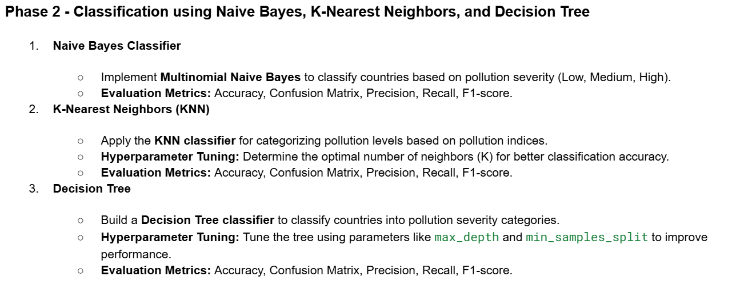

In [84]:
from sklearn.model_selection import cross_val_score 
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Used in the previous project 

k_values = range(1, 21)
cv_scores = []


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())
    

best_k = k_values[cv_scores.index(max(cv_scores))]
print("\n","Best K:", best_k)
print("Best CV Accuracy:", max(cv_scores), "\n")


knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)


y_pred = knn.predict(X_test_scaled)

print(" Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


 Best K: 15
Best CV Accuracy: 0.78125 

 Accuracy: 0.75
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.60      0.38      0.46         8
           2       0.77      0.93      0.84        29

    accuracy                           0.75        40
   macro avg       0.46      0.44      0.44        40
weighted avg       0.68      0.75      0.70        40

Confusion Matrix:
 [[ 0  0  3]
 [ 0  3  5]
 [ 0  2 27]]


In [ ]:
#print("K =", k, " Accuracy =",  max(cv_scores))

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



dt = DecisionTreeClassifier(
    criterion='gini',   # using gini we getting more     
    max_depth=5,             
    min_samples_split=10,    
    random_state=42
)
dt.fit(X_train_scaled, y_train)


y_pred_dt = dt.predict(X_test_scaled)


print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.75
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.56      0.62      0.59         8
           2       0.81      0.86      0.83        29

    accuracy                           0.75        40
   macro avg       0.45      0.50      0.47        40
weighted avg       0.70      0.75      0.72        40

Confusion Matrix:
 [[ 0  0  3]
 [ 0  5  3]
 [ 0  4 25]]


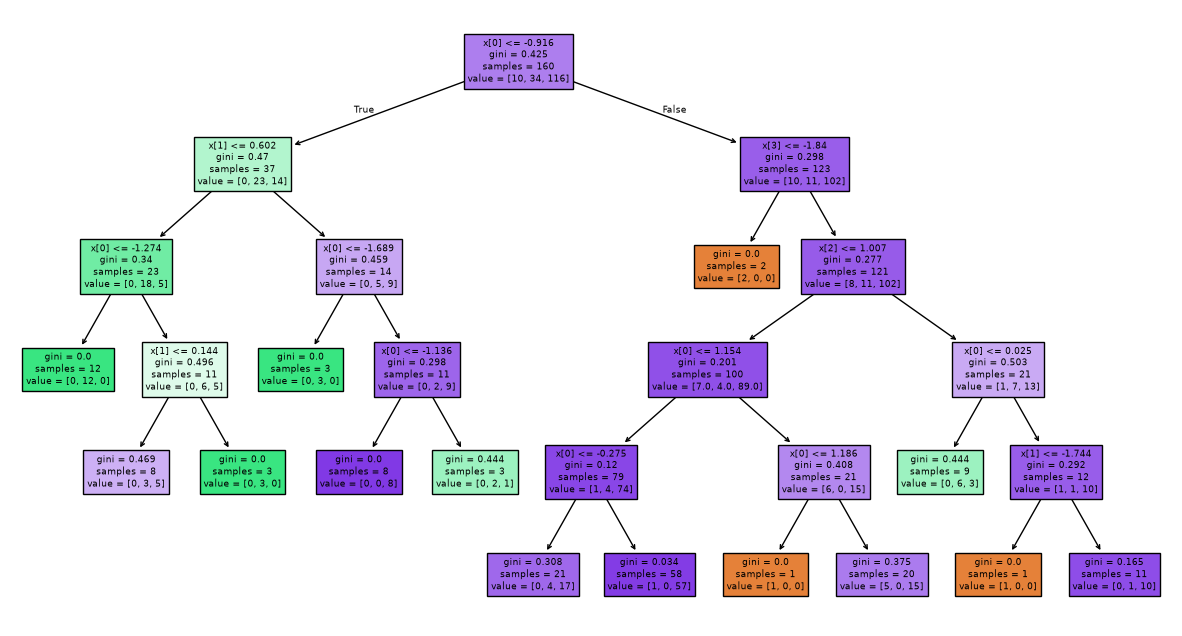

In [74]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(dt, filled=True)
plt.show()

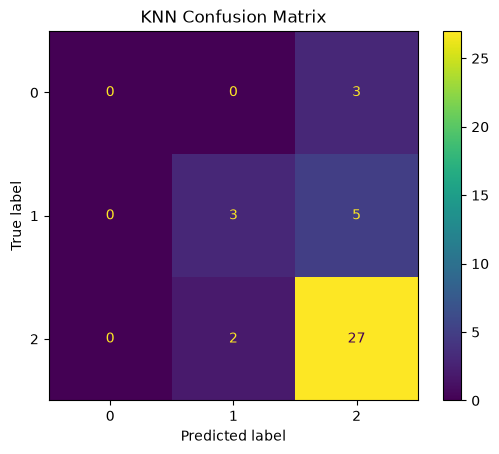

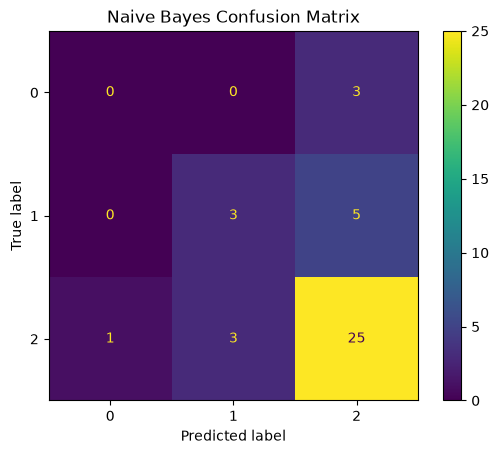

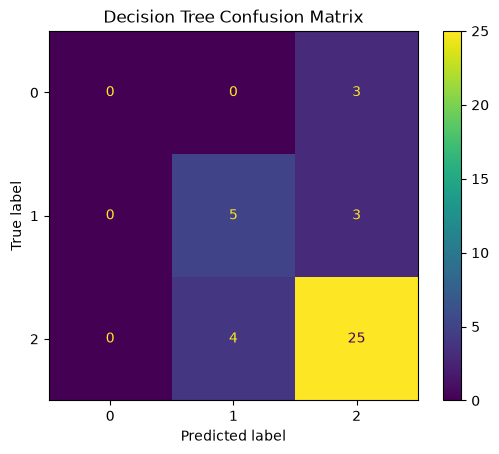

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("KNN Confusion Matrix")
plt.show()



ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.title("Naive Bayes Confusion Matrix")
plt.show()




ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Phase 3: Reporting and Insights

## Model Comparison

Three machine learning classifiers were trained and evaluated to classify the target classes. The models were compared using **Accuracy, Precision, Recall, and F1-Score** (weighted average).

### Performance Comparison

| Model | Accuracy | Precision | Recall | F1-Score |
|--------|---------:|----------:|-------:|---------:|
| Naive Bayes | **70.00%** | **0.65** | **0.70** | **0.67** |
| K-Nearest Neighbors (KNN) *(K = 15)* | **75.00%** | **0.68** | **0.75** | **0.70** |
| Decision Tree | **75.00%** | **0.70** | **0.75** | **0.72** |

---

# Best Model Recommendation

Based on the evaluation metrics, the **Decision Tree Classifier** is the recommended model for this project.

### Reasons

- The **highest overall accuracy (75%)**, tied with KNN.
- Produced the **highest weighted Precision (0.70)**.
- Achieved the **highest weighted F1-Score (0.72)**

# Conclusion

Among the evaluated machine learning models, the **Decision Tree Classifier** demonstrated the best overall performance. Although both **Decision Tree** and **K-Nearest Neighbors (KNN)** achieved an accuracy of **75%**, the Decision Tree achieved the highest weighted **Precision (0.70)** and **F1-Score (0.72)**, making it the most reliable model for this dataset.